# Adzuna Job Ads: AI Exposure Analysis for Slides

**Purpose**: Generate slide-ready figures and tables for the beamer progress deck.

**Outputs**:
- Key metrics summary
- Exposure distribution histogram
- SOC major group / category breakdown
- Geographic variation (LAD-level)
- Example high/low exposure jobs

In [ ]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

In [ ]:
import aisi_economy_index as proj
from aisi_economy_index import const

In [ ]:
import json
import asyncio
from typing import Optional, Tuple, Dict, Any, List
import adulib.llm as llm
import inspect

In [ ]:
from dotenv import load_dotenv

load_dotenv() 

In [ ]:
from pydantic import BaseModel, ValidationError, conint, confloat


In [ ]:
from pathlib import Path


In [ ]:
BASE_DIR = Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/db_30_0_excel")
OUT_DIR = Path(str(const.data_path)) / "eval_dfs"
OUT_DIR.mkdir(exist_ok=True)

In [ ]:
# =============================================================================
# 1. PATHS AND PROJECT LAYOUT
# =============================================================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import warnings
import json as json_lib
warnings.filterwarnings('ignore')
from tqdm import tqdm

# Define paths (relative to notebook location)
BASE = Path(".")
DATA_DIR = BASE / "adzuna_analysis"

# NEW: Use JSONL with weighted SOC assignments instead of matched parquet
JSONL_PATH = DATA_DIR / "493k_adzuna_job_ads_weights_scores.jsonl"

# Keep adzuna monthly files for metadata (LAD, title, category)
ADZUNA_DIR = DATA_DIR / "adzuna_2022"

# SOC scores (Felten, task exposure, humanness, etc.)
SOC_CODES_DIR = BASE / "SOC_codes"
SOC_SCORES_PATH = SOC_CODES_DIR / "merged_all_scores.csv"

# Geographic data
GEO_DATA_DIR = BASE / "data" / "geo"
LAD_BOUNDARY_PATH = GEO_DATA_DIR / "LAD_Dec_2022_UK_BGC.geojson"

# Output directories
OUT_DIR = BASE / "outputs" / "slides_mvp"
OUT_FIG = OUT_DIR / "figures"
OUT_TAB = OUT_DIR / "tables"

# Create output directories
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)

print("Data sources:")
print(f"  JSONL (weighted SOC): {JSONL_PATH} (exists: {JSONL_PATH.exists()})")
print(f"  SOC scores: {SOC_SCORES_PATH} (exists: {SOC_SCORES_PATH.exists()})")
print(f"  LAD boundaries: {LAD_BOUNDARY_PATH} (exists: {LAD_BOUNDARY_PATH.exists()})")
print(f"\nOutput directories created:")
print(f"  Figures: {OUT_FIG}")
print(f"  Tables:  {OUT_TAB}")

# =============================================================================
# SLIDE-READY PLOT SETTINGS (matplotlib only, no seaborn)
# =============================================================================
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    # Typography
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    # Clean style
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
})

# Consistent colour scheme
PRIMARY_COLOR = '#2C3E50'      # Dark blue-grey (main bars/elements)
ACCENT_COLOR = '#E74C3C'       # Red (high exposure / highlights)
SECONDARY_COLOR = '#3498DB'    # Blue (secondary elements)
GREY_LIGHT = '#BDC3C7'         # Light grey (backgrounds, low emphasis)
GREY_MED = '#7F8C8D'           # Medium grey (annotations)

print("\n✓ Plot settings configured for slides")

Data sources:
  JSONL (weighted SOC): adzuna_analysis/493k_adzuna_job_ads_weights_scores.jsonl (exists: True)
  SOC scores: SOC_codes/merged_all_scores.csv (exists: True)
  LAD boundaries: data/geo/LAD_Dec_2022_UK_BGC.geojson (exists: True)

Output directories created:
  Figures: outputs/slides_mvp/figures
  Tables:  outputs/slides_mvp/tables

✓ Plot settings configured for slides


In [ ]:
# =============================================================================
# 2. CONSTANTS AND MAPPINGS
# =============================================================================

# O*NET Major Group names (2-digit prefix codes)
ONET_MAJOR_NAMES = {
    11: "Management", 
    13: "Business & Financial", 
    15: "Computer & Mathematical",
    17: "Architecture & Engineering", 
    19: "Life, Physical & Social Science",
    21: "Community & Social Service", 
    23: "Legal", 
    25: "Educational Instruction",
    27: "Arts, Design, Entertainment", 
    29: "Healthcare Practitioners",
    31: "Healthcare Support", 
    33: "Protective Service", 
    35: "Food Preparation & Serving",
    37: "Building & Grounds Cleaning", 
    39: "Personal Care & Service", 
    41: "Sales",
    43: "Office & Administrative", 
    45: "Farming, Fishing, Forestry",
    47: "Construction & Extraction", 
    49: "Installation, Maintenance, Repair",
    51: "Production", 
    53: "Transportation & Material Moving"
}

# Score columns we'll compute
SCORE_COLUMNS = ['felten_score', 'task_exposure_norm', 'humanness_avg',
                 'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl', 'vulnerability']

print(f"O*NET Major Groups defined: {len(ONET_MAJOR_NAMES)}")
print(f"Score columns to compute: {len(SCORE_COLUMNS)}")

O*NET Major Groups defined: 22
Score columns to compute: 7


In [ ]:
# =============================================================================
# 3. LOAD DATA
# =============================================================================

# -----------------------------------------------------------------------------
# 3.1 Load SOC-level scores from merged_all_scores.csv
# -----------------------------------------------------------------------------
print("Loading SOC-level scores...")
if not SOC_SCORES_PATH.exists():
    raise FileNotFoundError(f"SOC scores file not found: {SOC_SCORES_PATH}")

soc_scores_df = pd.read_csv(SOC_SCORES_PATH)
print(f"  Loaded {len(soc_scores_df):,} occupations")

# Check available score columns
score_col_candidates = ['felten_score', 'task_exposure_norm', 'humanness_avg', 
                        'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl', 'vulnerability']
available_score_cols = [c for c in score_col_candidates if c in soc_scores_df.columns]
print(f"  Score columns available: {available_score_cols}")

# Build lookup: Title -> {score_name: value, soc_major: code}
soc_lookup = {}
for _, row in soc_scores_df.iterrows():
    title = row['Title']
    soc_lookup[title] = {col: row[col] for col in available_score_cols if pd.notna(row[col])}
    if 'soc_major' in soc_scores_df.columns and pd.notna(row['soc_major']):
        soc_lookup[title]['soc_major'] = int(row['soc_major'])
    if 'soc_major_name' in soc_scores_df.columns:
        soc_lookup[title]['soc_major_name'] = row['soc_major_name']

print(f"  Built lookup for {len(soc_lookup):,} occupation titles")

# -----------------------------------------------------------------------------
# 3.2 Load JSONL with job ads and weighted SOC assignments
# -----------------------------------------------------------------------------
print("\nLoading JSONL with weighted SOC assignments...")
if not JSONL_PATH.exists():
    raise FileNotFoundError(f"JSONL file not found: {JSONL_PATH}")

job_records = []
with open(JSONL_PATH, 'r') as f:
    for line in f:
        record = json_lib.loads(line)
        job_records.append(record)

print(f"  Loaded {len(job_records):,} job ads")

# -----------------------------------------------------------------------------
# 3.3 Load monthly parquets for METADATA (LAD, title, category, etc.)
# -----------------------------------------------------------------------------
print("\nLoading Adzuna monthly parquets for metadata...")
adzuna_files = sorted(ADZUNA_DIR.glob("*month*.parquet")) if ADZUNA_DIR.exists() else []
print(f"  Found {len(adzuna_files)} monthly files")

if len(adzuna_files) > 0:
    adzuna_dfs = [pd.read_parquet(f) for f in adzuna_files]
    adzuna_meta = pd.concat(adzuna_dfs, ignore_index=True)
    
    # Identify ID column
    id_candidates = ['id', 'job_id', 'Id', 'ID']
    adzuna_id_col = None
    for col in id_candidates:
        if col in adzuna_meta.columns:
            adzuna_id_col = col
            break
    
    if adzuna_id_col:
        adzuna_meta = adzuna_meta.drop_duplicates(subset=[adzuna_id_col])
        print(f"  After deduplication by '{adzuna_id_col}': {len(adzuna_meta):,} rows")
    else:
        print(f"  Warning: No ID column found in parquets")
    
    print(f"  Metadata columns available: {[c for c in adzuna_meta.columns if c in ['id', 'title', 'category_name', 'LAD22NM', 'LAD22CD', 'soc2020_major_group']]}")
else:
    adzuna_meta = None
    adzuna_id_col = None
    print("  No monthly parquet files found - metadata will be unavailable")

print("\n✓ All data sources loaded")

Loading SOC-level scores...
  Loaded 894 occupations
  Score columns available: ['felten_score', 'task_exposure_norm', 'humanness_avg', 'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl', 'vulnerability']
  Built lookup for 894 occupation titles

Loading JSONL with weighted SOC assignments...
  Loaded 493,000 job ads

Loading Adzuna monthly parquets for metadata...
  Found 11 monthly files
  After deduplication by 'id': 550,593 rows
  Metadata columns available: ['LAD22CD', 'LAD22NM', 'category_name', 'id', 'soc2020_major_group', 'title']

✓ All data sources loaded


In [ ]:
# =============================================================================
# 4. ANALYZE DATA & COVERAGE
# =============================================================================

# Check metadata
if adzuna_meta is not None:
    print(f"ADZUNA METADATA: {len(adzuna_meta):,} rows")
    print(f"  ID column: {adzuna_id_col}")
    print(f"  Columns: {list(adzuna_meta.columns)[:10]}...")
else:
    print("ADZUNA METADATA: Not loaded")

# Check JSONL
print(f"\nJSONL RECORDS: {len(job_records):,} job ads")
sample = job_records[0]
print(f"  Sample job_id: {sample['job_id']}")
print(f"  Occupations in sample: {len(sample.get('weighted_score_dict', {}))}")

# Check SOC lookup
print(f"\nSOC LOOKUP: {len(soc_lookup):,} occupations")
sample_occ = list(soc_lookup.keys())[0]
print(f"  Sample: {sample_occ}")
print(f"  Scores: {list(soc_lookup[sample_occ].keys())}")

# Check coverage
all_jsonl_occupations = set()
for record in job_records[:5000]:  # Sample first 5000
    all_jsonl_occupations.update(record.get('weighted_score_dict', {}).keys())

matched = all_jsonl_occupations.intersection(set(soc_lookup.keys()))
print(f"\nCOVERAGE (first 5000 jobs):")
print(f"  Unique occupations in JSONL: {len(all_jsonl_occupations)}")
print(f"  Matched to SOC scores: {len(matched)} ({len(matched)/len(all_jsonl_occupations)*100:.1f}%)")

ADZUNA METADATA: 550,593 rows
  ID column: id
  Columns: ['LAD22CD', 'LAD22NM', 'category_id', 'category_name', 'company_id', 'company_raw', 'contract_time', 'contract_type', 'date_created', 'description']...

JSONL RECORDS: 493,000 job ads
  Sample job_id: 2852063840
  Occupations in sample: 6

SOC LOOKUP: 894 occupations
  Sample: Data Entry Keyers
  Scores: ['felten_score', 'task_exposure_norm', 'humanness_avg', 'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl', 'vulnerability', 'soc_major', 'soc_major_name']

COVERAGE (first 5000 jobs):
  Unique occupations in JSONL: 831
  Matched to SOC scores: 831 (100.0%)


In [ ]:
# =============================================================================
# 5. CALCULATE WEIGHTED SCORES AND MERGE WITH METADATA
# =============================================================================

def calc_weighted_score(weighted_dict, score_name, lookup):
    """Calculate weighted average score for a job."""
    if not weighted_dict:
        return np.nan
    
    total_score = 0.0
    total_weight = 0.0
    
    for occ_title, weight in weighted_dict.items():
        if occ_title in lookup and score_name in lookup[occ_title]:
            score_val = lookup[occ_title][score_name]
            if pd.notna(score_val):
                total_score += weight * score_val
                total_weight += weight
    
    if total_weight > 0:
        return total_score / total_weight
    return np.nan

def get_dominant_occupation(weighted_dict):
    """Return occupation with highest weight."""
    if not weighted_dict:
        return None
    return max(weighted_dict.items(), key=lambda x: x[1])[0]

def get_dominant_soc_major(weighted_dict, lookup):
    """Return SOC major group of dominant occupation."""
    dom_occ = get_dominant_occupation(weighted_dict)
    if dom_occ and dom_occ in lookup:
        return lookup[dom_occ].get('soc_major', None)
    return None

# -----------------------------------------------------------------------------
# Build dataframe with weighted scores from JSONL
# -----------------------------------------------------------------------------
print("Computing weighted scores for all job ads...")

results = []
for record in tqdm(job_records, desc="Processing jobs"):
    job_id = record['job_id']
    weighted_dict = record.get('weighted_score_dict', {})
    
    row = {
        'job_id': job_id,
        'n_occupations': len(weighted_dict),
        'dominant_occupation': get_dominant_occupation(weighted_dict),
        'onet_major': get_dominant_soc_major(weighted_dict, soc_lookup),
    }
    
    # Calculate all weighted scores - use consistent column names
    row['felten_score'] = calc_weighted_score(weighted_dict, 'felten_score', soc_lookup)
    row['task_exposure_norm'] = calc_weighted_score(weighted_dict, 'task_exposure_norm', soc_lookup)
    row['humanness_avg'] = calc_weighted_score(weighted_dict, 'humanness_avg', soc_lookup)
    row['physical_imp_lvl'] = calc_weighted_score(weighted_dict, 'physical_imp_lvl', soc_lookup)
    row['emotional_imp_lvl'] = calc_weighted_score(weighted_dict, 'emotional_imp_lvl', soc_lookup)
    row['creative_imp_lvl'] = calc_weighted_score(weighted_dict, 'creative_imp_lvl', soc_lookup)
    row['vulnerability'] = calc_weighted_score(weighted_dict, 'vulnerability', soc_lookup)
    
    results.append(row)

scores_df = pd.DataFrame(results)
scores_df['onet_major_name'] = scores_df['onet_major'].map(ONET_MAJOR_NAMES)

print(f"  Computed scores for {len(scores_df):,} job ads")
print(f"  felten_score valid: {scores_df['felten_score'].notna().sum():,}")

# -----------------------------------------------------------------------------
# Merge with metadata from parquets
# -----------------------------------------------------------------------------
if adzuna_meta is not None and adzuna_id_col is not None:
    print(f"\nMerging with metadata on job_id...")
    
    df = scores_df.merge(
        adzuna_meta, 
        left_on='job_id', 
        right_on=adzuna_id_col, 
        how='inner'
    )
    
    print(f"  Matched {len(df):,} of {len(scores_df):,} jobs ({len(df)/len(scores_df)*100:.1f}%)")
else:
    print("\nNo metadata available - using scores only")
    df = scores_df.copy()

# Summary
print(f"\n✓ Final dataframe: {len(df):,} job ads")
print(f"\nScore coverage:")
for col in ['felten_score', 'task_exposure_norm', 'humanness_avg']:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"  {col}: {n_valid:,} ({n_valid/len(df)*100:.1f}%)")

In [ ]:
# =============================================================================
# 6. SET EXPOSURE COLUMN AND THRESHOLDS
# =============================================================================

# Primary exposure column is felten_score (weighted)
EXPOSURE_COL = 'felten_score'

if EXPOSURE_COL not in df.columns or df[EXPOSURE_COL].isna().all():
    raise ValueError(f"Exposure column '{EXPOSURE_COL}' not available or all NA")

# Drop rows without valid exposure scores
df = df.dropna(subset=[EXPOSURE_COL])
print(f"Jobs with valid {EXPOSURE_COL}: {len(df):,}")

# Detect scale and set threshold
exposure_max = df[EXPOSURE_COL].max()
exposure_min = df[EXPOSURE_COL].min()

# Felten scores are on 0-1 scale (typically 0.5-0.65 range)
if exposure_max <= 1.0:
    EXPOSURE_SCALE = "0-1"
    HIGH_THRESHOLD = 0.62  # ~median, adjust as needed
elif exposure_max <= 2.0:
    EXPOSURE_SCALE = "0-1 (some outliers)"
    HIGH_THRESHOLD = 0.62
else:
    EXPOSURE_SCALE = "0-100"
    HIGH_THRESHOLD = 62

print(f"\nExposure statistics ({EXPOSURE_COL}):")
print(f"  Min: {exposure_min:.4f}")
print(f"  Max: {exposure_max:.4f}")
print(f"  Mean: {df[EXPOSURE_COL].mean():.4f}")
print(f"  Median: {df[EXPOSURE_COL].median():.4f}")
print(f"  Std: {df[EXPOSURE_COL].std():.4f}")
print(f"\nDetected scale: {EXPOSURE_SCALE}")
print(f"High exposure threshold: >= {HIGH_THRESHOLD}")

high_exposure_pct = (df[EXPOSURE_COL] >= HIGH_THRESHOLD).mean() * 100
print(f"Jobs with high exposure: {high_exposure_pct:.1f}%")

Jobs with valid felten_score: 457,017

Exposure statistics (felten_score):
  Min: 0.5244
  Max: 0.6338
  Mean: 0.5938
  Median: 0.6004
  Std: 0.0256

Detected scale: 0-1
High exposure threshold: >= 0.62
Jobs with high exposure: 16.7%


## A. Key Metrics Table

In [ ]:
# =============================================================================
# A. KEY METRICS TABLE
# =============================================================================

metrics = {
    'Total Job Ads': len(df),
    'Unique Job IDs': df['job_id'].nunique() if 'job_id' in df.columns else len(df),
    'Unique Occupations': df['dominant_occupation'].nunique() if 'dominant_occupation' in df.columns else 'N/A',
    'O*NET Major Groups': df['onet_major'].nunique() if 'onet_major' in df.columns else 'N/A',
}

# Exposure statistics
metrics['Mean Felten Score'] = round(df[EXPOSURE_COL].mean(), 4)
metrics['Median Felten Score'] = round(df[EXPOSURE_COL].median(), 4)
metrics['Std Dev'] = round(df[EXPOSURE_COL].std(), 4)
metrics['P10 Felten Score'] = round(df[EXPOSURE_COL].quantile(0.10), 4)
metrics['P90 Felten Score'] = round(df[EXPOSURE_COL].quantile(0.90), 4)

# High exposure share
metrics[f'% High Exposure (>={HIGH_THRESHOLD})'] = f"{high_exposure_pct:.1f}%"

# Other scores if available
if 'task_exposure_norm' in df.columns:
    metrics['Mean Task Exposure'] = round(df['task_exposure_norm'].mean(), 4)
if 'humanness_avg' in df.columns:
    metrics['Mean Humanness'] = round(df['humanness_avg'].mean(), 4)

# Create DataFrame
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])

# Save
metrics_df.to_csv(OUT_TAB / "key_metrics.csv", index=False)
print(f"Saved: {OUT_TAB / 'key_metrics.csv'}")

print("\n### Key Metrics\n")
print(metrics_df.to_markdown(index=False))

Saved: outputs/slides_mvp/tables/key_metrics.csv

### Key Metrics

| Metric                   | Value   |
|:-------------------------|:--------|
| Total Job Ads            | 457017  |
| Unique Job IDs           | 457017  |
| Unique Occupations       | 893     |
| O*NET Major Groups       | 22      |
| Mean Felten Score        | 0.5938  |
| Median Felten Score      | 0.6004  |
| Std Dev                  | 0.0256  |
| P10 Felten Score         | 0.5543  |
| P90 Felten Score         | 0.623   |
| % High Exposure (>=0.62) | 16.7%   |
| Mean Task Exposure       | 0.3749  |
| Mean Humanness           | 0.5305  |


## B. Exposure Distribution

Saved: outputs/slides_mvp/figures/uk_exposure_distribution.png


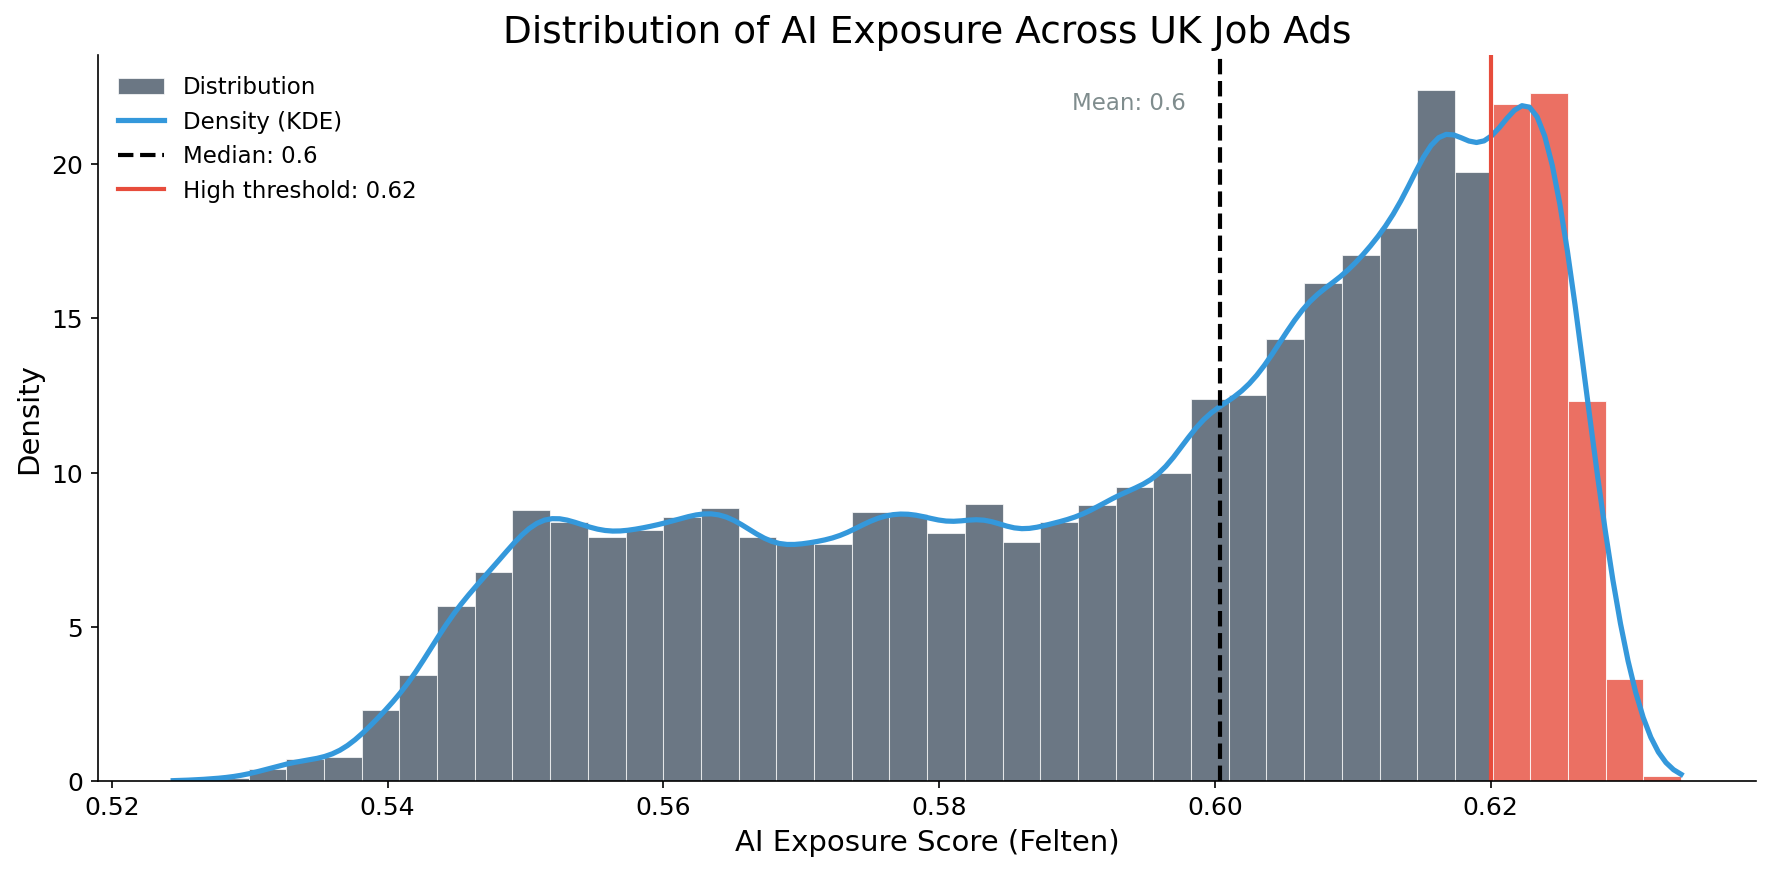

In [ ]:
# =============================================================================
# B. EXPOSURE DISTRIBUTION FIGURE (Histogram + KDE)
# =============================================================================
from scipy import stats

exposure_data = df[EXPOSURE_COL].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
n, bins, patches = ax.hist(
    exposure_data, 
    bins=40, 
    density=True,  # Normalize for KDE overlay
    edgecolor='white',
    linewidth=0.5,
    color=PRIMARY_COLOR,
    alpha=0.7,
    label='Distribution'
)

# Color high exposure bins with accent color
for patch, b in zip(patches, bins[:-1]):
    if b >= HIGH_THRESHOLD:
        patch.set_facecolor(ACCENT_COLOR)
        patch.set_alpha(0.8)

# KDE overlay
kde_x = np.linspace(exposure_data.min(), exposure_data.max(), 200)
kde = stats.gaussian_kde(exposure_data)
ax.plot(kde_x, kde(kde_x), color=SECONDARY_COLOR, linewidth=2.5, label='Density (KDE)')

# Add vertical lines for key statistics
median_val = exposure_data.median()
ax.axvline(median_val, color='black', linestyle='--', linewidth=2, 
           label=f'Median: {median_val:.1f}')
ax.axvline(HIGH_THRESHOLD, color=ACCENT_COLOR, linestyle='-', linewidth=2, 
           label=f'High threshold: {HIGH_THRESHOLD}')

ax.set_xlabel('AI Exposure Score (Felten)', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.set_title('Distribution of AI Exposure Across UK Job Ads', fontsize=18)

# Clean legend
ax.legend(fontsize=11, frameon=False, loc='upper left')

# Add key stat annotation
ax.annotate(
    f'{high_exposure_pct:.0f}% of jobs\nhigh exposure',
    xy=(HIGH_THRESHOLD + 5, ax.get_ylim()[1] * 0.7),
    fontsize=12, ha='left', va='top',
    color=ACCENT_COLOR, fontweight='bold'
)

# Add mean annotation
mean_val = exposure_data.mean()
ax.annotate(
    f'Mean: {mean_val:.1f}',
    xy=(mean_val, ax.get_ylim()[1] * 0.95),
    fontsize=11, ha='center', va='top',
    color=GREY_MED
)

plt.tight_layout()
plt.savefig(OUT_FIG / "uk_exposure_distribution.png", dpi=300, bbox_inches='tight')
print(f"Saved: {OUT_FIG / 'uk_exposure_distribution.png'}")
plt.show()

## C. Exposure by Occupation Type

In [ ]:
# =============================================================================
# C. EXPOSURE BY O*NET MAJOR GROUP
# =============================================================================

# We use the O*NET major group from the dominant occupation
GROUP_COL = 'onet_major'
GROUP_NAME_COL = 'onet_major_name'

n_with_group = df[GROUP_COL].notna().sum()
print(f"Jobs with O*NET major group: {n_with_group:,} ({n_with_group/len(df)*100:.1f}%)")
print(f"Unique major groups: {df[GROUP_COL].nunique()}")

Jobs with O*NET major group: 457,017 (100.0%)
Unique major groups: 22


=== INDIVIDUAL OCCUPATIONS ===
Occupations with n >= 100: 542
Showing top 25 by job count
Saved: outputs/slides_mvp/figures/individual_occupation_exposure.png


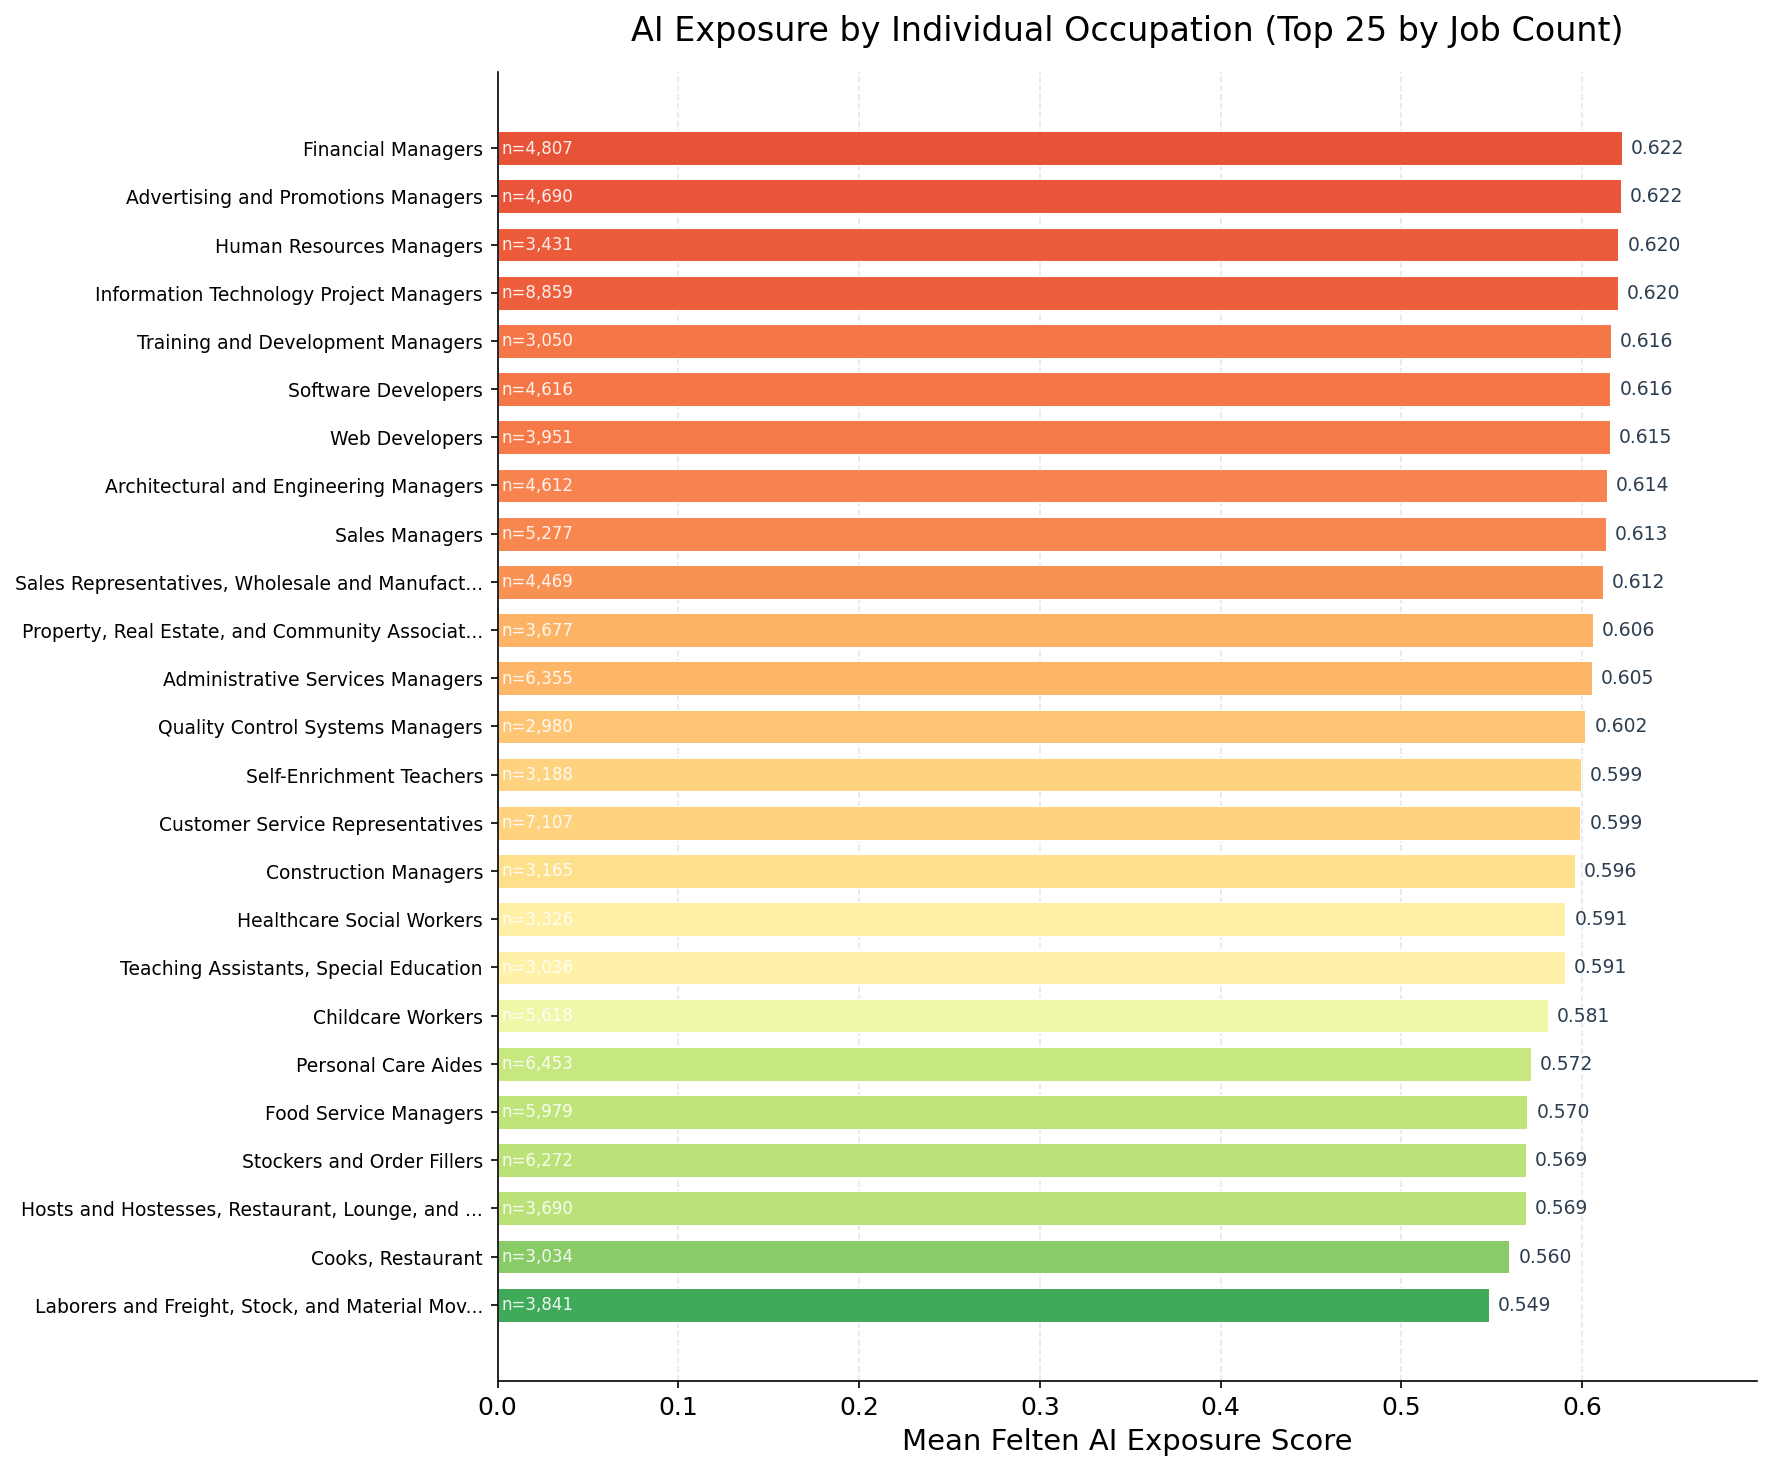

Saved: outputs/slides_mvp/tables/individual_occupation_summary.csv

=== O*NET MAJOR GROUPS ===
Major groups with data: 22
Saved: outputs/slides_mvp/figures/onet_major_group_exposure.png


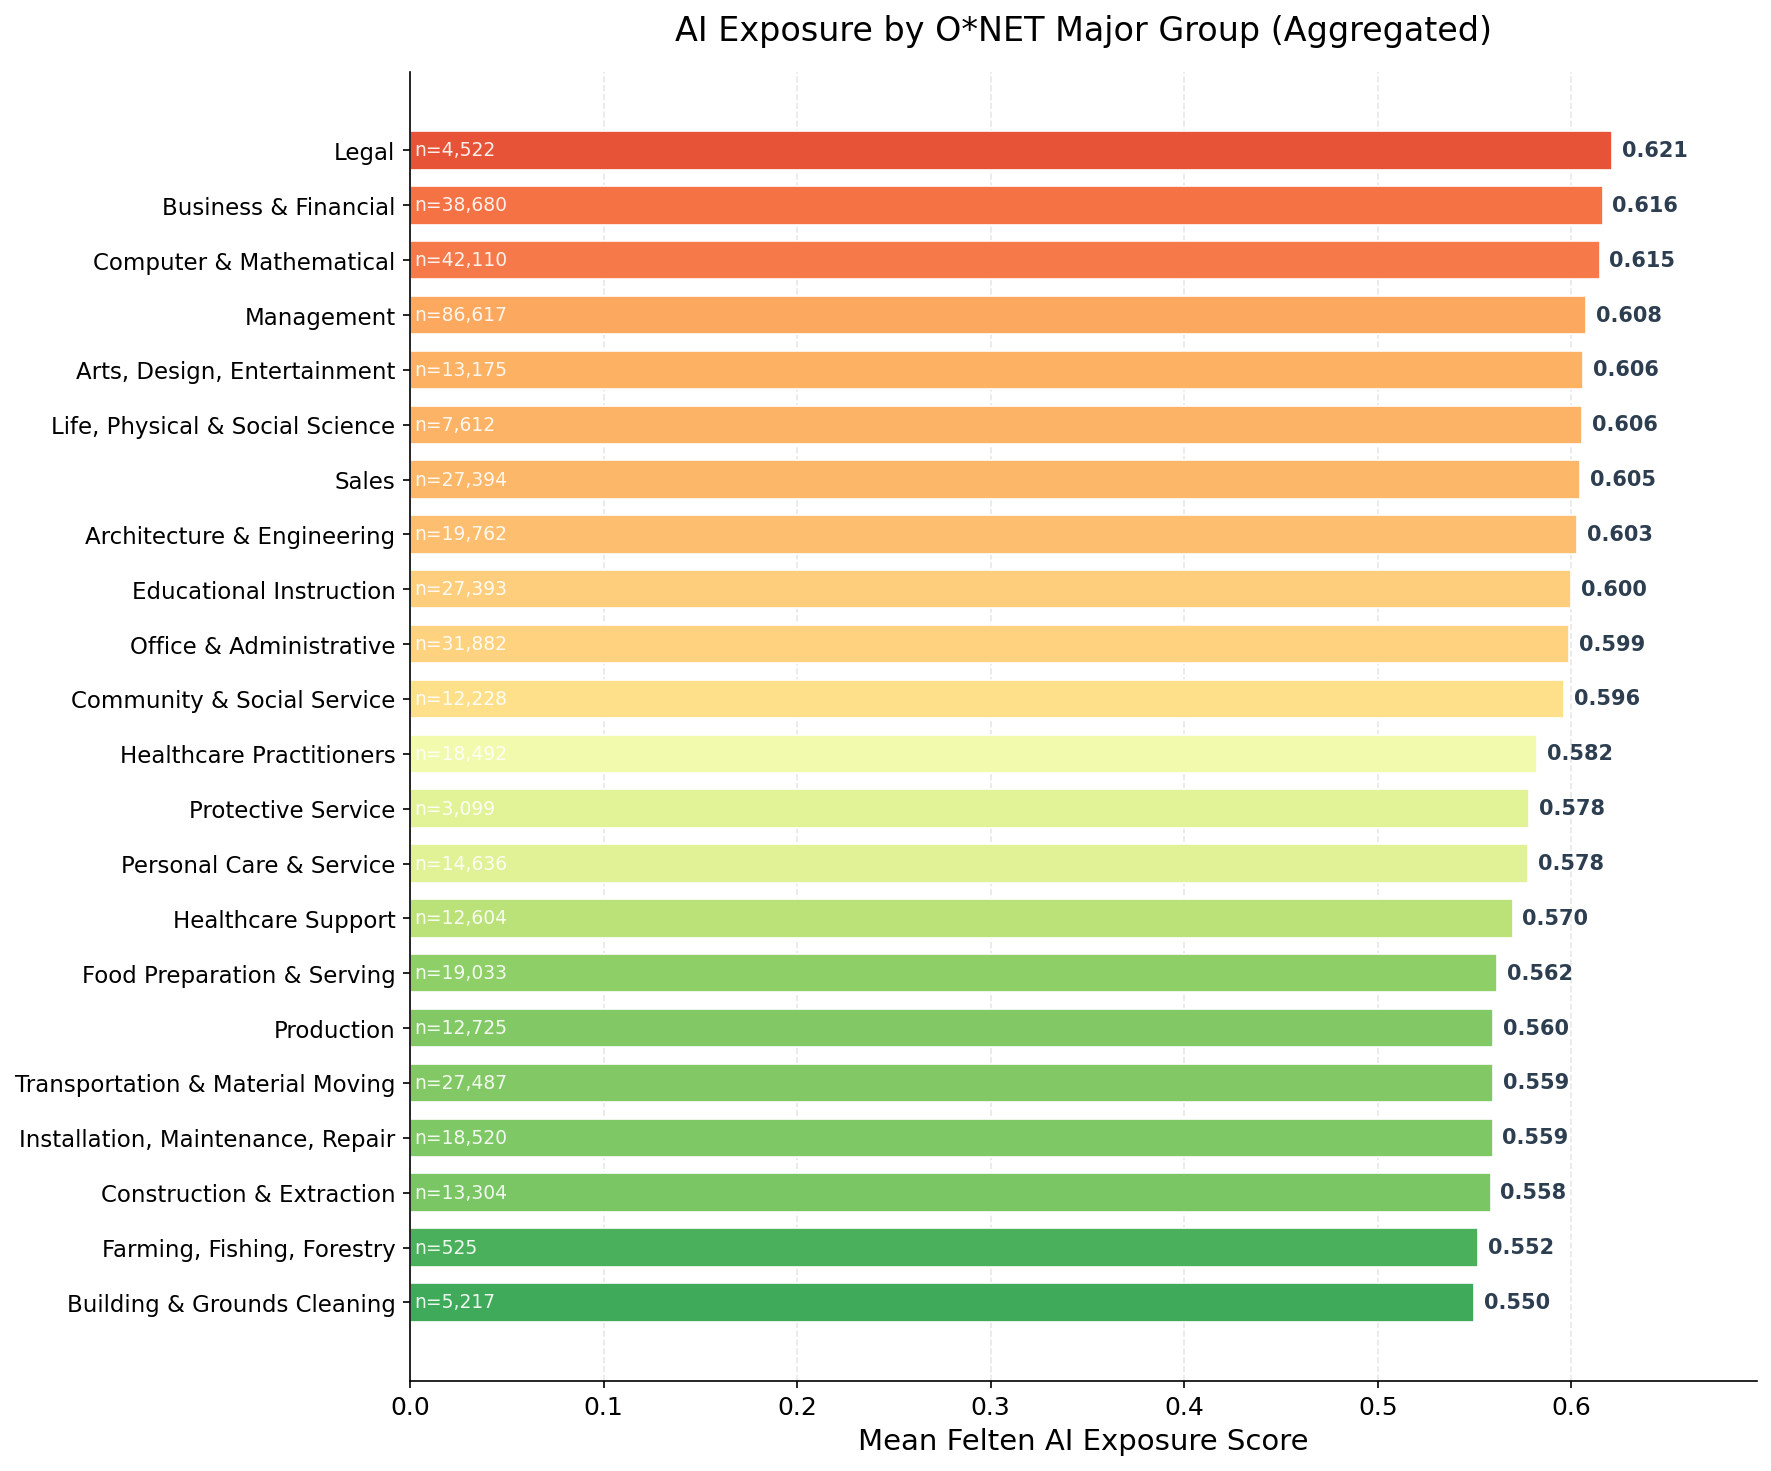

Saved: outputs/slides_mvp/tables/onet_major_group_summary.csv


In [ ]:
# =============================================================================
# C.2 EXPOSURE BY OCCUPATION - INDIVIDUAL & MAJOR GROUP VIEWS
# =============================================================================

# -----------------------------------------------------------------------------
# PART 1: Individual Occupations (Top 25 by job count)
# -----------------------------------------------------------------------------
print("=== INDIVIDUAL OCCUPATIONS ===")

occ_stats = df.groupby('dominant_occupation').agg(
    mean_exposure=(EXPOSURE_COL, 'mean'),
    median_exposure=(EXPOSURE_COL, 'median'),
    n_jobs=(EXPOSURE_COL, 'count')
).reset_index()

# Filter to occupations with enough jobs and take top 25 by count
MIN_OCC_N = 100
occ_stats_filtered = occ_stats[occ_stats['n_jobs'] >= MIN_OCC_N].copy()
occ_stats_top25 = occ_stats_filtered.nlargest(25, 'n_jobs').sort_values('mean_exposure', ascending=True)

print(f"Occupations with n >= {MIN_OCC_N}: {len(occ_stats_filtered)}")
print(f"Showing top 25 by job count")

# Plot individual occupations
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(occ_stats_top25))
norm_vals = (occ_stats_top25['mean_exposure'] - occ_stats_top25['mean_exposure'].min()) / \
            (occ_stats_top25['mean_exposure'].max() - occ_stats_top25['mean_exposure'].min() + 0.001)
colors = plt.cm.RdYlGn_r(norm_vals * 0.7 + 0.15)

bars = ax.barh(y_pos, occ_stats_top25['mean_exposure'], 
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

ax.set_yticks(y_pos)
# Truncate long names
labels = [n[:45] + '...' if len(str(n)) > 45 else n for n in occ_stats_top25['dominant_occupation']]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Mean Felten AI Exposure Score', fontsize=14)
ax.set_title('AI Exposure by Individual Occupation (Top 25 by Job Count)', fontsize=16, pad=15)

# Add value labels
for i, (_, row) in enumerate(occ_stats_top25.iterrows()):
    ax.text(row['mean_exposure'] + 0.005, i, f"{row['mean_exposure']:.3f}", 
            va='center', ha='left', fontsize=9, color=PRIMARY_COLOR)
    ax.text(0.002, i, f"n={int(row['n_jobs']):,}", 
            va='center', ha='left', fontsize=8, color='white', alpha=0.9)

ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, occ_stats_top25['mean_exposure'].max() * 1.12)

plt.tight_layout()
plt.savefig(OUT_FIG / "individual_occupation_exposure.png", dpi=300, bbox_inches='tight')
print(f"Saved: {OUT_FIG / 'individual_occupation_exposure.png'}")
plt.show()

# Save table
occ_stats_filtered.sort_values('mean_exposure', ascending=False).to_csv(
    OUT_TAB / "individual_occupation_summary.csv", index=False)
print(f"Saved: {OUT_TAB / 'individual_occupation_summary.csv'}")

# -----------------------------------------------------------------------------
# PART 2: O*NET Major Groups (aggregated view)
# -----------------------------------------------------------------------------
print("\n=== O*NET MAJOR GROUPS ===")

if df['onet_major'].notna().sum() > 100:
    group_stats = df.dropna(subset=['onet_major']).groupby('onet_major').agg(
        mean_exposure=(EXPOSURE_COL, 'mean'),
        median_exposure=(EXPOSURE_COL, 'median'),
        std_exposure=(EXPOSURE_COL, 'std'),
        n_jobs=(EXPOSURE_COL, 'count')
    ).reset_index()
    
    group_stats['group_label'] = group_stats['onet_major'].map(ONET_MAJOR_NAMES)
    group_stats = group_stats.dropna(subset=['group_label'])
    group_stats = group_stats.sort_values('mean_exposure', ascending=True)
    
    print(f"Major groups with data: {len(group_stats)}")
    
    # Plot major groups
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = np.arange(len(group_stats))
    norm_vals = (group_stats['mean_exposure'] - group_stats['mean_exposure'].min()) / \
                (group_stats['mean_exposure'].max() - group_stats['mean_exposure'].min() + 0.001)
    colors = plt.cm.RdYlGn_r(norm_vals * 0.7 + 0.15)
    
    bars = ax.barh(y_pos, group_stats['mean_exposure'], 
                   color=colors, edgecolor='white', linewidth=0.8, height=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(group_stats['group_label'], fontsize=11)
    ax.set_xlabel('Mean Felten AI Exposure Score', fontsize=14)
    ax.set_title('AI Exposure by O*NET Major Group (Aggregated)', fontsize=16, pad=15)
    
    for i, (_, row) in enumerate(group_stats.iterrows()):
        ax.text(row['mean_exposure'] + 0.005, i, f"{row['mean_exposure']:.3f}", 
                va='center', ha='left', fontsize=10, fontweight='bold', color=PRIMARY_COLOR)
        ax.text(0.002, i, f"n={int(row['n_jobs']):,}", 
                va='center', ha='left', fontsize=9, color='white', alpha=0.9)
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xlim(0, group_stats['mean_exposure'].max() * 1.12)
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "onet_major_group_exposure.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {OUT_FIG / 'onet_major_group_exposure.png'}")
    plt.show()
    
    # Save table
    save_stats = group_stats[['group_label', 'mean_exposure', 'median_exposure', 'std_exposure', 'n_jobs']].copy()
    save_stats.columns = ['O*NET Major Group', 'Mean Exposure', 'Median Exposure', 'Std Dev', 'N Jobs']
    save_stats = save_stats.round(4)
    save_stats.to_csv(OUT_TAB / "onet_major_group_summary.csv", index=False)
    print(f"Saved: {OUT_TAB / 'onet_major_group_summary.csv'}")
else:
    print("Insufficient data for major group analysis")

## D. Geographic Variation

In [ ]:
# =============================================================================
# D. GEOGRAPHIC VARIATION
# =============================================================================

# Detect geographic columns from metadata
GEO_COL = None
GEO_CODE_COL = None

if 'LAD22NM' in df.columns and df['LAD22NM'].notna().sum() > 1000:
    GEO_COL = 'LAD22NM'
if 'LAD22CD' in df.columns and df['LAD22CD'].notna().sum() > 1000:
    GEO_CODE_COL = 'LAD22CD'

if GEO_COL:
    print(f"Geographic name column: {GEO_COL} ({df[GEO_COL].notna().sum():,} valid)")
if GEO_CODE_COL:
    print(f"Geographic code column: {GEO_CODE_COL} ({df[GEO_CODE_COL].notna().sum():,} valid)")

if not GEO_COL and not GEO_CODE_COL:
    print("⚠ No geographic columns found in data")

Geographic name column: LAD22NM (278,505 valid)
Geographic code column: LAD22CD (278,505 valid)


In [ ]:
if GEO_COL:
    # Aggregate by geography
    geo_stats = df.groupby(GEO_COL).agg(
        mean_exposure=(EXPOSURE_COL, 'mean'),
        median_exposure=(EXPOSURE_COL, 'median'),
        n_jobs=(EXPOSURE_COL, 'count')
    ).reset_index()
    
    # Filter to areas with sufficient data
    MIN_N = 50
    geo_stats_filtered = geo_stats[geo_stats['n_jobs'] >= MIN_N].copy()
    geo_stats_filtered = geo_stats_filtered.sort_values('mean_exposure', ascending=False)
    
    print(f"\n{len(geo_stats_filtered)} areas with n >= {MIN_N} jobs")
    
    # Top/Bottom 10 table
    top_10 = geo_stats_filtered.head(10).copy()
    top_10['rank_type'] = 'Top 10 (Highest Exposure)'
    
    bottom_10 = geo_stats_filtered.tail(10).copy()
    bottom_10['rank_type'] = 'Bottom 10 (Lowest Exposure)'
    
    top_bottom = pd.concat([top_10, bottom_10])
    top_bottom.to_csv(OUT_TAB / "top_bottom_lads.csv", index=False)
    print(f"\nSaved: {OUT_TAB / 'top_bottom_lads.csv'}")
    
    print("\n### Top 10 Highest Exposure Areas")
    print(top_10[[GEO_COL, 'mean_exposure', 'n_jobs']].to_string(index=False))
    
    print("\n### Bottom 10 Lowest Exposure Areas")
    print(bottom_10[[GEO_COL, 'mean_exposure', 'n_jobs']].to_string(index=False))
else:
    geo_stats_filtered = None
    print("Skipping geographic analysis - no geographic column available.")


365 areas with n >= 50 jobs

Saved: outputs/slides_mvp/tables/top_bottom_lads.csv

### Top 10 Highest Exposure Areas
       LAD22NM  mean_exposure  n_jobs
City of London       0.610880    5553
   Westminster       0.606144    9904
       Belfast       0.605529    2255
     Islington       0.605404    1456
 Malvern Hills       0.603945     487
       Hackney       0.602745    1243
    Manchester       0.602700   12389
Waltham Forest       0.601796    1248
         Leeds       0.599717    5220
       Wealden       0.599405    1555

### Bottom 10 Lowest Exposure Areas
            LAD22NM  mean_exposure  n_jobs
         Harborough       0.578450     536
         East Devon       0.577942     438
   Isle of Anglesey       0.577743      91
West Dunbartonshire       0.577678     181
               Arun       0.577402     477
   South Derbyshire       0.577024     321
East Dunbartonshire       0.576738     142
      Pembrokeshire       0.576296     214
      North Norfolk       0.576147     2

Loading LAD boundaries...
  Loaded 374 LAD polygons
  Matched 370 of 374 LADs
Saved: outputs/slides_mvp/figures/lad_choropleth.png


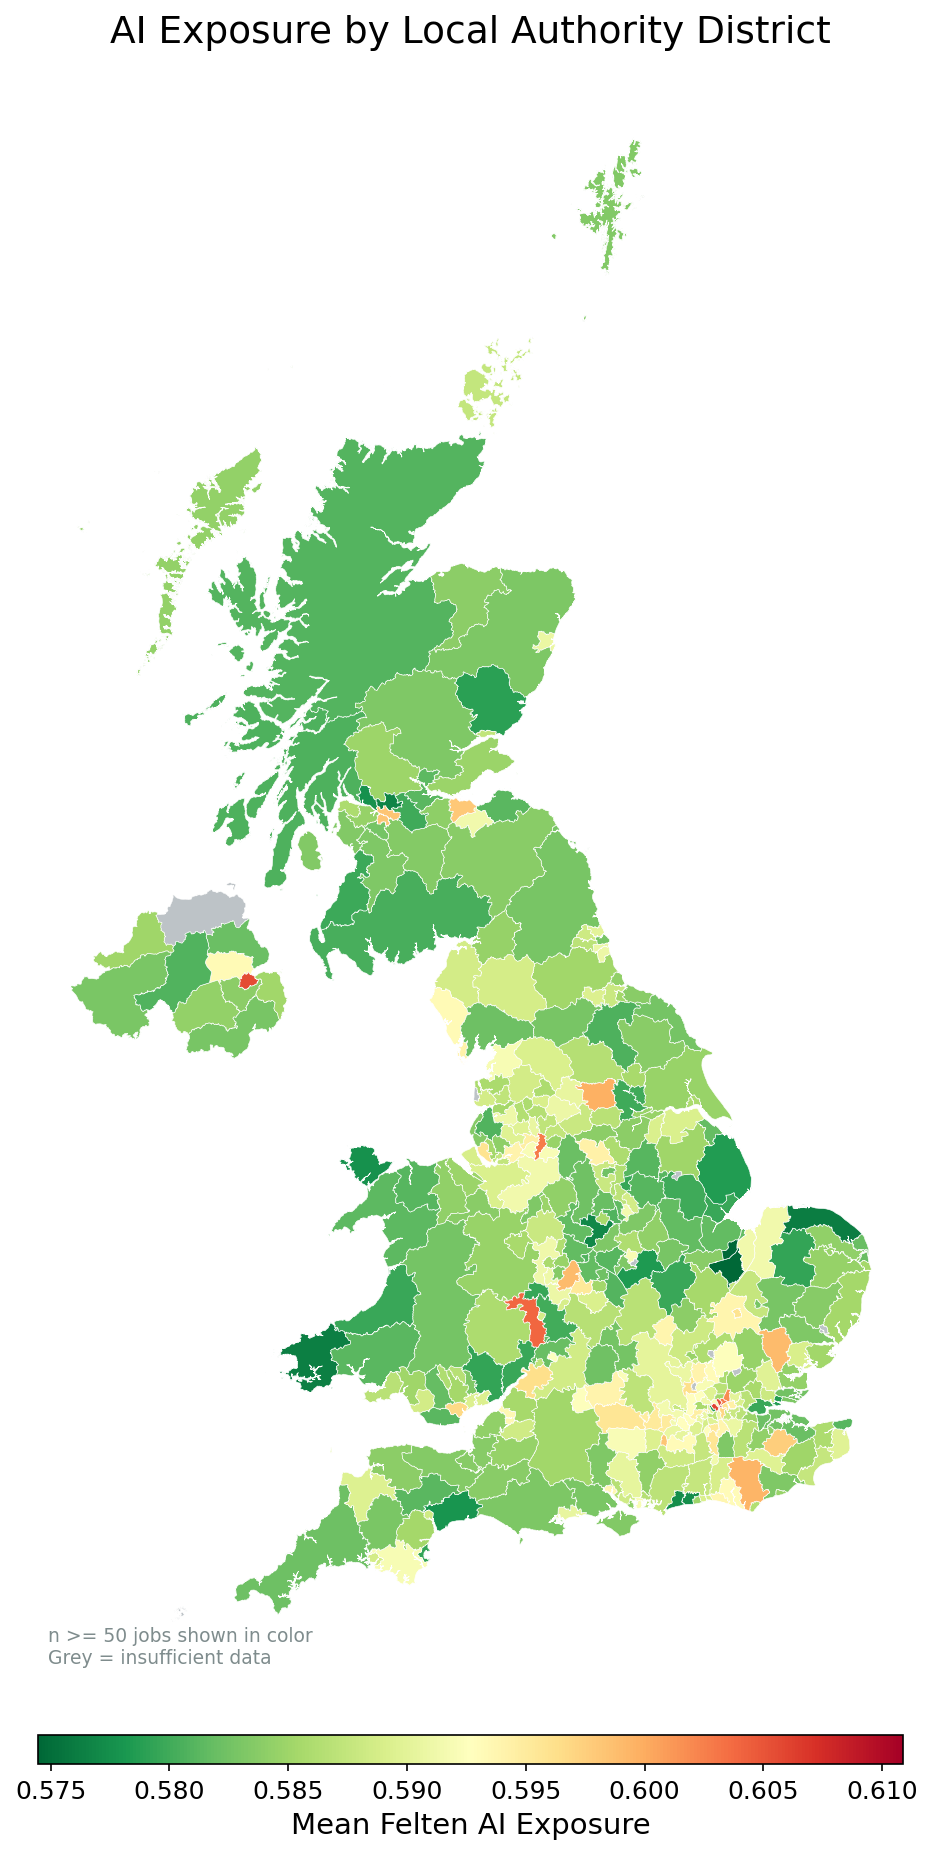

In [ ]:
# =============================================================================
# D.3 LAD CHOROPLETH MAP
# =============================================================================

if GEO_COL and geo_stats_filtered is not None and len(geo_stats_filtered) > 0:
    try:
        import geopandas as gpd
        HAS_GEOPANDAS = True
    except ImportError:
        HAS_GEOPANDAS = False
        print("geopandas not installed - skipping choropleth")
    
    if HAS_GEOPANDAS and LAD_BOUNDARY_PATH.exists():
        print(f"Loading LAD boundaries...")
        gdf = gpd.read_file(LAD_BOUNDARY_PATH)
        print(f"  Loaded {len(gdf)} LAD polygons")
        
        # Use LAD code for joining if available
        if GEO_CODE_COL and GEO_CODE_COL in df.columns:
            geo_for_map = df.groupby(GEO_CODE_COL).agg(
                mean_exposure=(EXPOSURE_COL, 'mean'),
                n_jobs=(EXPOSURE_COL, 'count')
            ).reset_index()
            join_col = GEO_CODE_COL
            gdf_join_col = 'LAD22CD' if 'LAD22CD' in gdf.columns else gdf.columns[0]
        else:
            geo_for_map = geo_stats.copy()
            join_col = GEO_COL
            gdf_join_col = 'LAD22NM' if 'LAD22NM' in gdf.columns else gdf.columns[1]
        
        # Merge
        merged_geo = gdf.merge(geo_for_map, left_on=gdf_join_col, right_on=join_col, how='left')
        matched_count = merged_geo['mean_exposure'].notna().sum()
        print(f"  Matched {matched_count} of {len(gdf)} LADs")
        
        # Apply n>=50 filter
        merged_geo['show_color'] = merged_geo['n_jobs'] >= MIN_N
        merged_geo['geometry'] = merged_geo['geometry'].simplify(tolerance=100)
        
        # Create figure
        fig, ax = plt.subplots(1, 1, figsize=(10, 14))
        
        # Plot LADs without enough data in grey
        merged_geo[~merged_geo['show_color']].plot(ax=ax, color=GREY_LIGHT, edgecolor='white', linewidth=0.2)
        
        # Plot LADs with sufficient data
        if merged_geo['show_color'].sum() > 0:
            merged_geo[merged_geo['show_color']].plot(
                column='mean_exposure', ax=ax, cmap='RdYlGn_r',
                edgecolor='white', linewidth=0.3, legend=True,
                legend_kwds={'label': 'Mean Felten AI Exposure', 'orientation': 'horizontal',
                            'shrink': 0.6, 'pad': 0.02, 'aspect': 30}
            )
        
        ax.set_title('AI Exposure by Local Authority District', fontsize=18, pad=10)
        ax.set_axis_off()
        ax.annotate(f'n >= {MIN_N} jobs shown in color\nGrey = insufficient data',
                   xy=(0.02, 0.02), xycoords='axes fraction', fontsize=9, color=GREY_MED)
        
        plt.tight_layout()
        plt.savefig(OUT_FIG / "lad_choropleth.png", dpi=300, bbox_inches='tight')
        print(f"Saved: {OUT_FIG / 'lad_choropleth.png'}")
        plt.show()
    else:
        HAS_GEOPANDAS = False
        print("LAD boundary file not found or geopandas unavailable")
else:
    HAS_GEOPANDAS = False
    print("Choropleth skipped - no geographic data")

Saved: outputs/slides_mvp/tables/london_vs_rest.csv

### London vs Rest of UK
    Region  N Jobs  Mean Exposure  Median Exposure    P10    P90
Rest of UK  419248         0.5933           0.5997 0.5538 0.6228
    London   37769         0.5991           0.6075 0.5602 0.6246
Saved: outputs/slides_mvp/figures/london_vs_rest.png


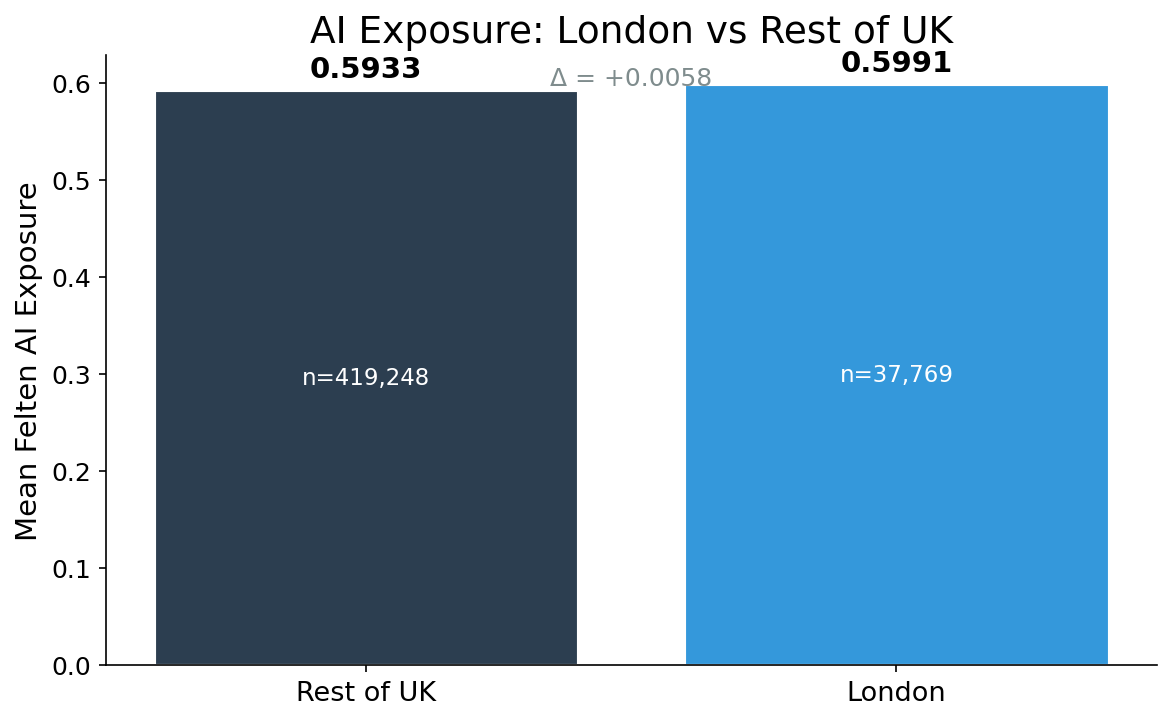

In [ ]:
# =============================================================================
# D.4 LONDON VS REST OF UK
# =============================================================================

if GEO_CODE_COL and GEO_CODE_COL in df.columns:
    # London boroughs have LAD codes starting with E09
    df['is_london'] = df[GEO_CODE_COL].fillna('').str.startswith('E09')
    
    london_stats = df.groupby('is_london').agg(
        n_jobs=(EXPOSURE_COL, 'count'),
        mean_exposure=(EXPOSURE_COL, 'mean'),
        median_exposure=(EXPOSURE_COL, 'median'),
        p10=(EXPOSURE_COL, lambda x: x.quantile(0.10)),
        p90=(EXPOSURE_COL, lambda x: x.quantile(0.90)),
    ).reset_index()
    
    london_stats['Region'] = london_stats['is_london'].map({True: 'London', False: 'Rest of UK'})
    london_stats = london_stats[['Region', 'n_jobs', 'mean_exposure', 'median_exposure', 'p10', 'p90']]
    london_stats.columns = ['Region', 'N Jobs', 'Mean Exposure', 'Median Exposure', 'P10', 'P90']
    
    for col in ['Mean Exposure', 'Median Exposure', 'P10', 'P90']:
        london_stats[col] = london_stats[col].round(4)
    
    london_stats.to_csv(OUT_TAB / "london_vs_rest.csv", index=False)
    print(f"Saved: {OUT_TAB / 'london_vs_rest.csv'}")
    
    print("\n### London vs Rest of UK")
    print(london_stats.to_string(index=False))
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(london_stats))
    bars = ax.bar(x, london_stats['Mean Exposure'], 
                  color=[SECONDARY_COLOR if r == 'London' else PRIMARY_COLOR 
                         for r in london_stats['Region']],
                  edgecolor='white', linewidth=1.5)
    
    ax.set_ylabel('Mean Felten AI Exposure', fontsize=14)
    ax.set_title('AI Exposure: London vs Rest of UK', fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(london_stats['Region'], fontsize=13)
    
    for bar, row in zip(bars, london_stats.itertuples()):
        height = bar.get_height()
        ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=14, fontweight='bold')
        ax.annotate(f'n={row._2:,}', xy=(bar.get_x() + bar.get_width() / 2, height / 2),
                    ha='center', va='center', fontsize=11, color='white')
    
    # Difference
    london_mean = london_stats.loc[london_stats['Region'] == 'London', 'Mean Exposure'].values[0]
    rest_mean = london_stats.loc[london_stats['Region'] == 'Rest of UK', 'Mean Exposure'].values[0]
    diff = london_mean - rest_mean
    ax.annotate(f'Δ = {diff:+.4f}', xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', fontsize=12, color=GREY_MED)
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "london_vs_rest.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {OUT_FIG / 'london_vs_rest.png'}")
    plt.show()
else:
    print("London vs Rest UK analysis skipped - no LAD code column")

## E. Example Jobs (High/Low Exposure)

In [ ]:
# =============================================================================
# E. EXAMPLE JOBS (High/Low Exposure)
# =============================================================================

# Find title column
title_col = 'title' if 'title' in df.columns else None

display_cols = ['job_id']
if title_col:
    display_cols.append(title_col)
display_cols.extend(['dominant_occupation', EXPOSURE_COL, 'onet_major_name'])
display_cols = [c for c in display_cols if c in df.columns]

print("### High Exposure Job Ads")
high_exp = df.nlargest(15, EXPOSURE_COL)[display_cols]
print(high_exp.to_string(index=False))

print("\n### Low Exposure Job Ads")
low_exp = df.nsmallest(15, EXPOSURE_COL)[display_cols]
print(low_exp.to_string(index=False))

# Save
examples = pd.concat([
    high_exp.assign(exposure_type='High'),
    low_exp.assign(exposure_type='Low')
])
examples.to_csv(OUT_TAB / "example_jobs_high_low.csv", index=False)
print(f"\nSaved: {OUT_TAB / 'example_jobs_high_low.csv'}")

### High Exposure Job Ads
    job_id                                                                               title      dominant_occupation  felten_score onet_major_name
2825267353                                                                Senior Product Owner Investment Fund Managers       0.63381      Management
2737336098                                                                        Product Lead Investment Fund Managers       0.63381      Management
2757361865                                                                  Investment Manager Investment Fund Managers       0.63381      Management
2785447297                                            Hedge Fund - Middle Office Trade Support Investment Fund Managers       0.63381      Management
2637092236               Senior Manager- Mergers & Acquisitions, Tax Transactions - Birmingham Investment Fund Managers       0.63381      Management
2903994742 Manager, Digital Asset Management, Real Assets Advisory, Financ

## F. Incorporate SOC-Level Conceptual Figures

In [ ]:
# =============================================================================
# F. COPY SOC-LEVEL ARTIFACTS (if available)
# =============================================================================

# Figures to copy
soc_figures = [
    "quadrant_analysis.png",
    "labeled_task_vs_humanness.png",
    "labeled_task_vs_felten.png",
    "labeled_humanness_vs_felten.png",
    "correlation_matrix.png",
    "3d_exposure_landscape.png",
    "vulnerability_extremes.png"
]

# Tables to copy
soc_tables = [
    "vulnerability_by_major_group.csv",
    "merged_all_scores.csv"
]

copied_files = []

if SOC_CODES_DIR.exists():
    print(f"SOC_CODES_DIR exists: {SOC_CODES_DIR}")
    
    # Copy figures
    for fig_name in soc_figures:
        src = SOC_CODES_DIR / fig_name
        if src.exists():
            dst = OUT_FIG / f"soc_{fig_name}"
            shutil.copy(src, dst)
            copied_files.append(str(dst))
            print(f"  Copied: {fig_name}")
    
    # Copy tables
    for tab_name in soc_tables:
        src = SOC_CODES_DIR / tab_name
        if src.exists():
            dst = OUT_TAB / f"soc_{tab_name}"
            shutil.copy(src, dst)
            copied_files.append(str(dst))
            print(f"  Copied: {tab_name}")
    
    if not copied_files:
        print("  No SOC artifacts found to copy.")
else:
    print(f"SOC_CODES_DIR not found: {SOC_CODES_DIR}")
    print("Skipping SOC artifact copy.")

SOC_CODES_DIR exists: SOC_codes
  Copied: quadrant_analysis.png
  Copied: labeled_task_vs_humanness.png
  Copied: labeled_task_vs_felten.png
  Copied: labeled_humanness_vs_felten.png
  Copied: correlation_matrix.png
  Copied: 3d_exposure_landscape.png
  Copied: vulnerability_extremes.png
  Copied: vulnerability_by_major_group.csv
  Copied: merged_all_scores.csv


## H. Task Automation & Human Presence Analysis

This section uses SOC-level scores from the precomputed files to analyze:
1. **Task-based automation potential** - which occupations/areas have jobs most susceptible to task automation
2. **Human presence requirements** - which occupations/areas require physical, emotional, and creative human presence

In [ ]:
# =============================================================================
# H.1 VERIFY WEIGHTED SCORES & DEFINE AGGREGATION UTILITIES
# =============================================================================

# We already computed weighted scores in cell 5 from the JSONL weighted SOC assignments.
# This section verifies those scores exist and defines reusable aggregation functions.

# The columns created in cell 5 are:
# felten_score, task_exposure_norm, humanness_avg, 
# physical_imp_lvl, emotional_imp_lvl, creative_imp_lvl, vulnerability

# Check which weighted scores are available
score_col_names = ['felten_score', 'task_exposure_norm', 'humanness_avg',
                   'physical_imp_lvl', 'emotional_imp_lvl', 'creative_imp_lvl', 
                   'vulnerability']

print("Weighted scores available in job ads data:")
for col in score_col_names:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"  ✓ {col}: {n_valid:,} valid values ({n_valid/len(df)*100:.1f}%)")
    else:
        print(f"  ✗ {col}: NOT FOUND")

# Create aliases for convenience (matching expected names in later cells)
if 'task_exposure_norm' in df.columns:
    df['task_exposure_score'] = df['task_exposure_norm']
if 'humanness_avg' in df.columns:
    df['humanness_score'] = df['humanness_avg']
if 'physical_imp_lvl' in df.columns:
    df['physical_presence'] = df['physical_imp_lvl']
if 'emotional_imp_lvl' in df.columns:
    df['emotional_presence'] = df['emotional_imp_lvl']
if 'creative_imp_lvl' in df.columns:
    df['creative_presence'] = df['creative_imp_lvl']

HAS_MULTI_SCORES = sum([c in df.columns for c in ['task_exposure_norm', 'humanness_avg']]) >= 2
print(f"\n✓ Multi-score analysis {'enabled' if HAS_MULTI_SCORES else 'disabled'}")

# =============================================================================
# AGGREGATION FUNCTION: Can aggregate to any level (occupation, major group, geography)
# =============================================================================
def aggregate_scores(df, group_col, score_cols, min_n=1, name_map=None):
    """
    Aggregate exposure scores by any grouping column.
    """
    # Filter to rows with valid group values
    df_valid = df.dropna(subset=[group_col])
    
    # Filter score_cols to only those that exist in df
    valid_score_cols = [c for c in score_cols if c in df_valid.columns]
    
    if len(valid_score_cols) == 0:
        print(f"Warning: No valid score columns found from {score_cols}")
        return pd.DataFrame({'n_jobs': [], 'group_name': []})
    
    # Build aggregation dict
    agg_dict = {'n_jobs': (valid_score_cols[0], 'count')}
    for col in valid_score_cols:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std'] = (col, 'std')
    
    # Aggregate
    result = df_valid.groupby(group_col).agg(**agg_dict).reset_index()
    
    # Apply minimum sample size filter
    result = result[result['n_jobs'] >= min_n].copy()
    
    # Add readable names if provided
    if name_map:
        result['group_name'] = result[group_col].map(name_map)
        result['group_name'] = result['group_name'].fillna(result[group_col].astype(str))
    else:
        result['group_name'] = result[group_col].astype(str)
    
    if len(valid_score_cols) > 0:
        return result.sort_values(f'{valid_score_cols[0]}_mean', ascending=False)
    return result

print("\n✓ aggregate_scores() function defined for flexible aggregation")

Weighted scores available in job ads data:
  ✓ felten_score: 457,017 valid values (100.0%)
  ✓ task_exposure_norm: 457,017 valid values (100.0%)
  ✓ humanness_avg: 457,017 valid values (100.0%)
  ✓ physical_imp_lvl: 457,017 valid values (100.0%)
  ✓ emotional_imp_lvl: 457,017 valid values (100.0%)
  ✓ creative_imp_lvl: 457,017 valid values (100.0%)
  ✓ vulnerability: 457,017 valid values (100.0%)

✓ Multi-score analysis enabled

✓ aggregate_scores() function defined for flexible aggregation


In [ ]:
# =============================================================================
# H.2 OCCUPATION-LEVEL ANALYSIS (GRANULAR)
# =============================================================================

print("=== OCCUPATION-LEVEL ANALYSIS ===")
print(f"Unique dominant occupations: {df['dominant_occupation'].nunique():,}")

# Top occupations by count
print("\nTop 15 most common occupations in job ads:")
top_occs = df['dominant_occupation'].value_counts().head(15)
for i, (occ, count) in enumerate(top_occs.items(), 1):
    pct = count / len(df) * 100
    print(f"  {i:>2}. {count:>6,} ({pct:>4.1f}%) - {occ}")

=== OCCUPATION-LEVEL ANALYSIS ===
Unique dominant occupations: 893

Top 15 most common occupations in job ads:
   1.  8,859 ( 1.9%) - Information Technology Project Managers
   2.  7,107 ( 1.6%) - Customer Service Representatives
   3.  6,453 ( 1.4%) - Personal Care Aides
   4.  6,355 ( 1.4%) - Administrative Services Managers
   5.  6,272 ( 1.4%) - Stockers and Order Fillers
   6.  5,979 ( 1.3%) - Food Service Managers
   7.  5,618 ( 1.2%) - Childcare Workers
   8.  5,277 ( 1.2%) - Sales Managers
   9.  4,807 ( 1.1%) - Financial Managers
  10.  4,690 ( 1.0%) - Advertising and Promotions Managers
  11.  4,616 ( 1.0%) - Software Developers
  12.  4,612 ( 1.0%) - Architectural and Engineering Managers
  13.  4,469 ( 1.0%) - Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products
  14.  3,951 ( 0.9%) - Web Developers
  15.  3,841 ( 0.8%) - Laborers and Freight, Stock, and Material Movers, Hand


Score columns for aggregation: ['felten_score', 'task_exposure_score', 'humanness_score']

=== OCCUPATION-LEVEL AGGREGATION (Granular) ===
Occupations with n>=10 jobs: 862
Total jobs covered: 456,826

=== O*NET MAJOR GROUP AGGREGATION ===
Major groups with n>=50 jobs: 22
Total jobs covered: 457,017

Saved: outputs/slides_mvp/figures/occupation_vs_major_group_comparison.png


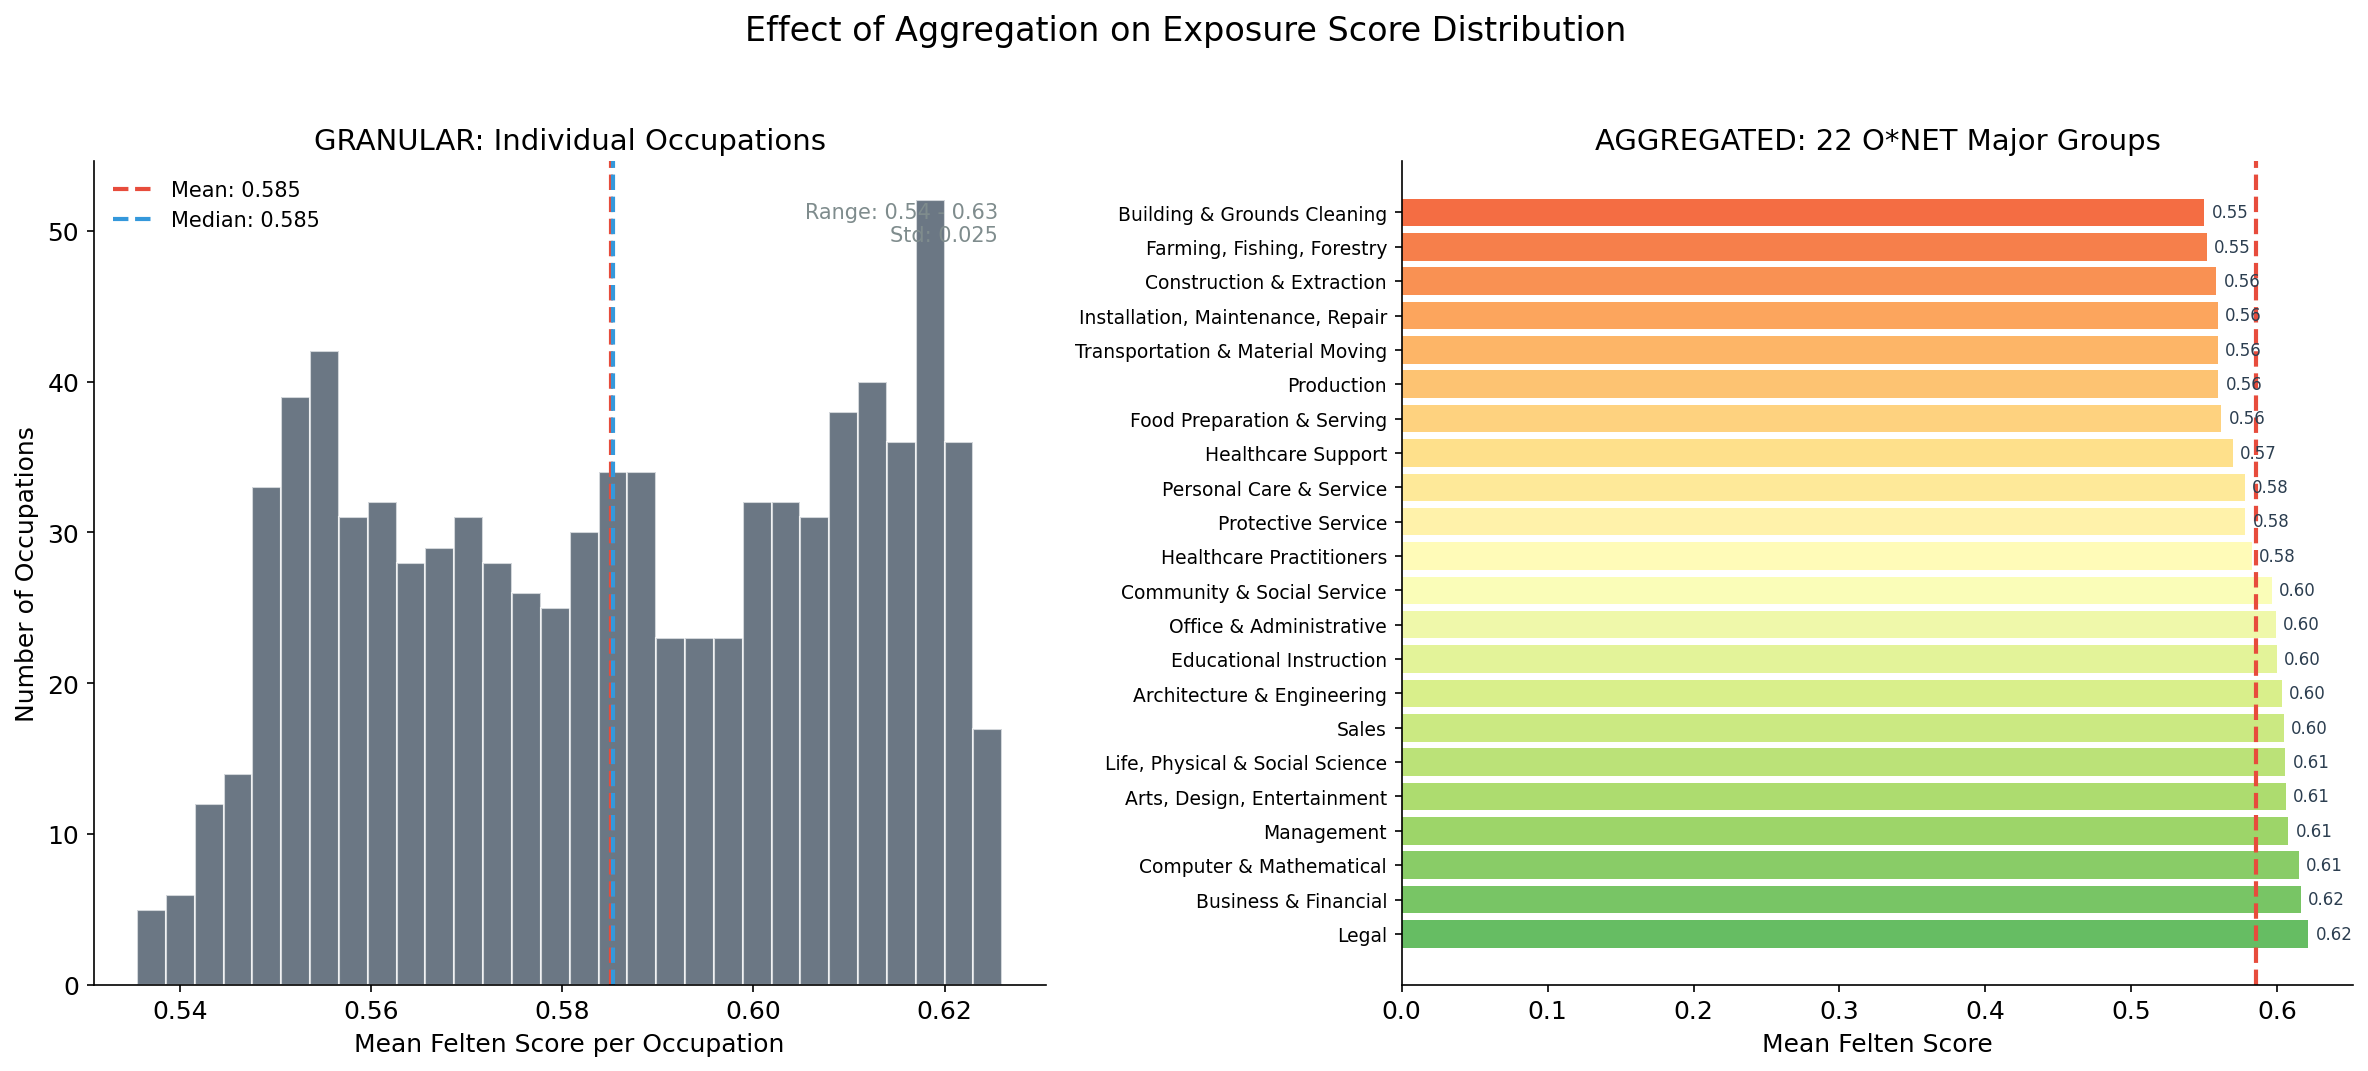


### Aggregation Level Comparison
                 Level  N Groups  Mean Felten  Std Dev   Min   Max
Individual Occupations       862        0.585    0.025 0.536 0.626
    O*NET Major Groups        22        0.586    0.024 0.550 0.621


In [ ]:
# =============================================================================
# H.3 OCCUPATION-LEVEL vs MAJOR GROUP AGGREGATION COMPARISON
# =============================================================================

# This demonstrates the difference between:
# 1. GRANULAR: ~870 individual O*NET occupations
# 2. AGGREGATED: 22 O*NET Major Groups

# Use actual column names from cell 5 (with aliases created in cell 24)
score_cols_for_agg = ['felten_score', 'task_exposure_score', 'humanness_score']
score_cols_available = [c for c in score_cols_for_agg if c in df.columns]

print(f"Score columns for aggregation: {score_cols_available}")

if len(score_cols_available) == 0:
    print("ERROR: No score columns available for aggregation")
    occ_level_stats = pd.DataFrame()
    major_group_stats = pd.DataFrame()
else:
    # -----------------------------------------------------------------------------
    # OCCUPATION-LEVEL AGGREGATION (granular)
    # -----------------------------------------------------------------------------
    print("\n=== OCCUPATION-LEVEL AGGREGATION (Granular) ===")
    occ_level_stats = aggregate_scores(
        df, 
        group_col='dominant_occupation',
        score_cols=score_cols_available,
        min_n=10  # At least 10 jobs per occupation
    )
    print(f"Occupations with n>=10 jobs: {len(occ_level_stats):,}")
    if len(occ_level_stats) > 0:
        print(f"Total jobs covered: {occ_level_stats['n_jobs'].sum():,}")
    
    # -----------------------------------------------------------------------------
    # MAJOR GROUP AGGREGATION 
    # -----------------------------------------------------------------------------
    print("\n=== O*NET MAJOR GROUP AGGREGATION ===")
    major_group_stats = aggregate_scores(
        df,
        group_col='onet_major',
        score_cols=score_cols_available,
        min_n=50,  # At least 50 jobs per major group
        name_map=ONET_MAJOR_NAMES
    )
    print(f"Major groups with n>=50 jobs: {len(major_group_stats):,}")
    if len(major_group_stats) > 0:
        print(f"Total jobs covered: {major_group_stats['n_jobs'].sum():,}")
    
    # -----------------------------------------------------------------------------
    # COMPARISON VISUALIZATION: Granular vs Aggregated Distribution
    # -----------------------------------------------------------------------------
    felten_col = 'felten_score_mean'
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Left: Distribution of mean Felten scores at OCCUPATION level
    ax1 = axes[0]
    if felten_col in occ_level_stats.columns and len(occ_level_stats) > 0:
        occ_felten = occ_level_stats[felten_col].dropna()
        if len(occ_felten) > 0:
            ax1.hist(occ_felten, bins=30, color=PRIMARY_COLOR, alpha=0.7, edgecolor='white')
            ax1.axvline(occ_felten.mean(), color=ACCENT_COLOR, linestyle='--', linewidth=2,
                        label=f'Mean: {occ_felten.mean():.3f}')
            ax1.axvline(occ_felten.median(), color=SECONDARY_COLOR, linestyle='--', linewidth=2,
                        label=f'Median: {occ_felten.median():.3f}')
            ax1.set_xlabel('Mean Felten Score per Occupation', fontsize=12)
            ax1.set_ylabel('Number of Occupations', fontsize=12)
            ax1.set_title(f'GRANULAR: {len(occ_level_stats):,} Individual Occupations', fontsize=14)
            ax1.legend(fontsize=10, frameon=False)
            ax1.annotate(f'Range: {occ_felten.min():.2f} - {occ_felten.max():.2f}\nStd: {occ_felten.std():.3f}',
                         xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
                         fontsize=10, color=GREY_MED)
        else:
            ax1.text(0.5, 0.5, 'No occupation-level data', ha='center', va='center', fontsize=14)
    else:
        ax1.text(0.5, 0.5, 'No occupation-level data', ha='center', va='center', fontsize=14)
    ax1.set_title('GRANULAR: Individual Occupations', fontsize=14)
    
    # Right: Distribution of mean Felten scores at MAJOR GROUP level
    ax2 = axes[1]
    if felten_col in major_group_stats.columns and len(major_group_stats) > 0:
        major_felten = major_group_stats[felten_col].dropna()
        if len(major_felten) > 0:
            bars = ax2.barh(range(len(major_group_stats)), major_group_stats[felten_col],
                            color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(major_group_stats))))
            ax2.set_yticks(range(len(major_group_stats)))
            ax2.set_yticklabels(major_group_stats['group_name'], fontsize=9)
            ax2.set_xlabel('Mean Felten Score', fontsize=12)
            ax2.set_title(f'AGGREGATED: {len(major_group_stats)} O*NET Major Groups', fontsize=14)
            ax2.axvline(major_felten.mean(), color=ACCENT_COLOR, linestyle='--', linewidth=2)
            
            # Add value labels
            for i, (_, row) in enumerate(major_group_stats.iterrows()):
                ax2.text(row[felten_col] + 0.005, i, f'{row[felten_col]:.2f}', 
                         va='center', fontsize=8, color=PRIMARY_COLOR)
        else:
            ax2.text(0.5, 0.5, 'No major group data', ha='center', va='center', fontsize=14)
    else:
        ax2.text(0.5, 0.5, 'No major group data', ha='center', va='center', fontsize=14)
        ax2.set_title('AGGREGATED: O*NET Major Groups', fontsize=14)
    
    plt.suptitle('Effect of Aggregation on Exposure Score Distribution', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_FIG / "occupation_vs_major_group_comparison.png", dpi=300, bbox_inches='tight')
    print(f"\nSaved: {OUT_FIG / 'occupation_vs_major_group_comparison.png'}")
    plt.show()
    
    # -----------------------------------------------------------------------------
    # SUMMARY STATISTICS TABLE
    # -----------------------------------------------------------------------------
    print("\n### Aggregation Level Comparison")
    comparison_stats = pd.DataFrame({
        'Level': ['Individual Occupations', 'O*NET Major Groups'],
        'N Groups': [len(occ_level_stats), len(major_group_stats)],
        'Mean Felten': [occ_level_stats[felten_col].mean() if felten_col in occ_level_stats.columns and len(occ_level_stats) > 0 else np.nan,
                       major_group_stats[felten_col].mean() if felten_col in major_group_stats.columns and len(major_group_stats) > 0 else np.nan],
        'Std Dev': [occ_level_stats[felten_col].std() if felten_col in occ_level_stats.columns and len(occ_level_stats) > 0 else np.nan,
                   major_group_stats[felten_col].std() if felten_col in major_group_stats.columns and len(major_group_stats) > 0 else np.nan],
        'Min': [occ_level_stats[felten_col].min() if felten_col in occ_level_stats.columns and len(occ_level_stats) > 0 else np.nan,
               major_group_stats[felten_col].min() if felten_col in major_group_stats.columns and len(major_group_stats) > 0 else np.nan],
        'Max': [occ_level_stats[felten_col].max() if felten_col in occ_level_stats.columns and len(occ_level_stats) > 0 else np.nan,
               major_group_stats[felten_col].max() if felten_col in major_group_stats.columns and len(major_group_stats) > 0 else np.nan],
    })
    print(comparison_stats.round(3).to_string(index=False))
    comparison_stats.to_csv(OUT_TAB / "aggregation_level_comparison.csv", index=False)

=== TOP OCCUPATIONS BY EXPOSURE SCORES (Granular Level) ===

### Top 15 Occupations with HIGHEST Felten AI Exposure:
   1. 0.626 - Economists (n=74)
   2. 0.626 - Statisticians (n=220)
   3. 0.625 - Investment Fund Managers (n=1,513)
   4. 0.625 - Industrial-Organizational Psychologists (n=142)
   5. 0.625 - Biostatisticians (n=112)
   6. 0.625 - Environmental Economists (n=48)
   7. 0.625 - Actuaries (n=293)
   8. 0.624 - Sociologists (n=47)
   9. 0.624 - Lawyers (n=2,202)
  10. 0.624 - Operations Research Analysts (n=271)
  11. 0.624 - Business Intelligence Analysts (n=1,286)
  12. 0.624 - Market Research Analysts and Marketing Specialists (n=1,933)
  13. 0.624 - Financial Examiners (n=2,618)
  14. 0.624 - Political Scientists (n=60)
  15. 0.623 - Search Marketing Strategists (n=2,159)

### Top 15 Occupations with LOWEST Felten AI Exposure:
   1. 0.536 - Helpers--Painters, Paperhangers, Plasterers, and Stucco Masons (n=190)
   2. 0.536 - Plasterers and Stucco Masons (n=76)
   3. 0.53

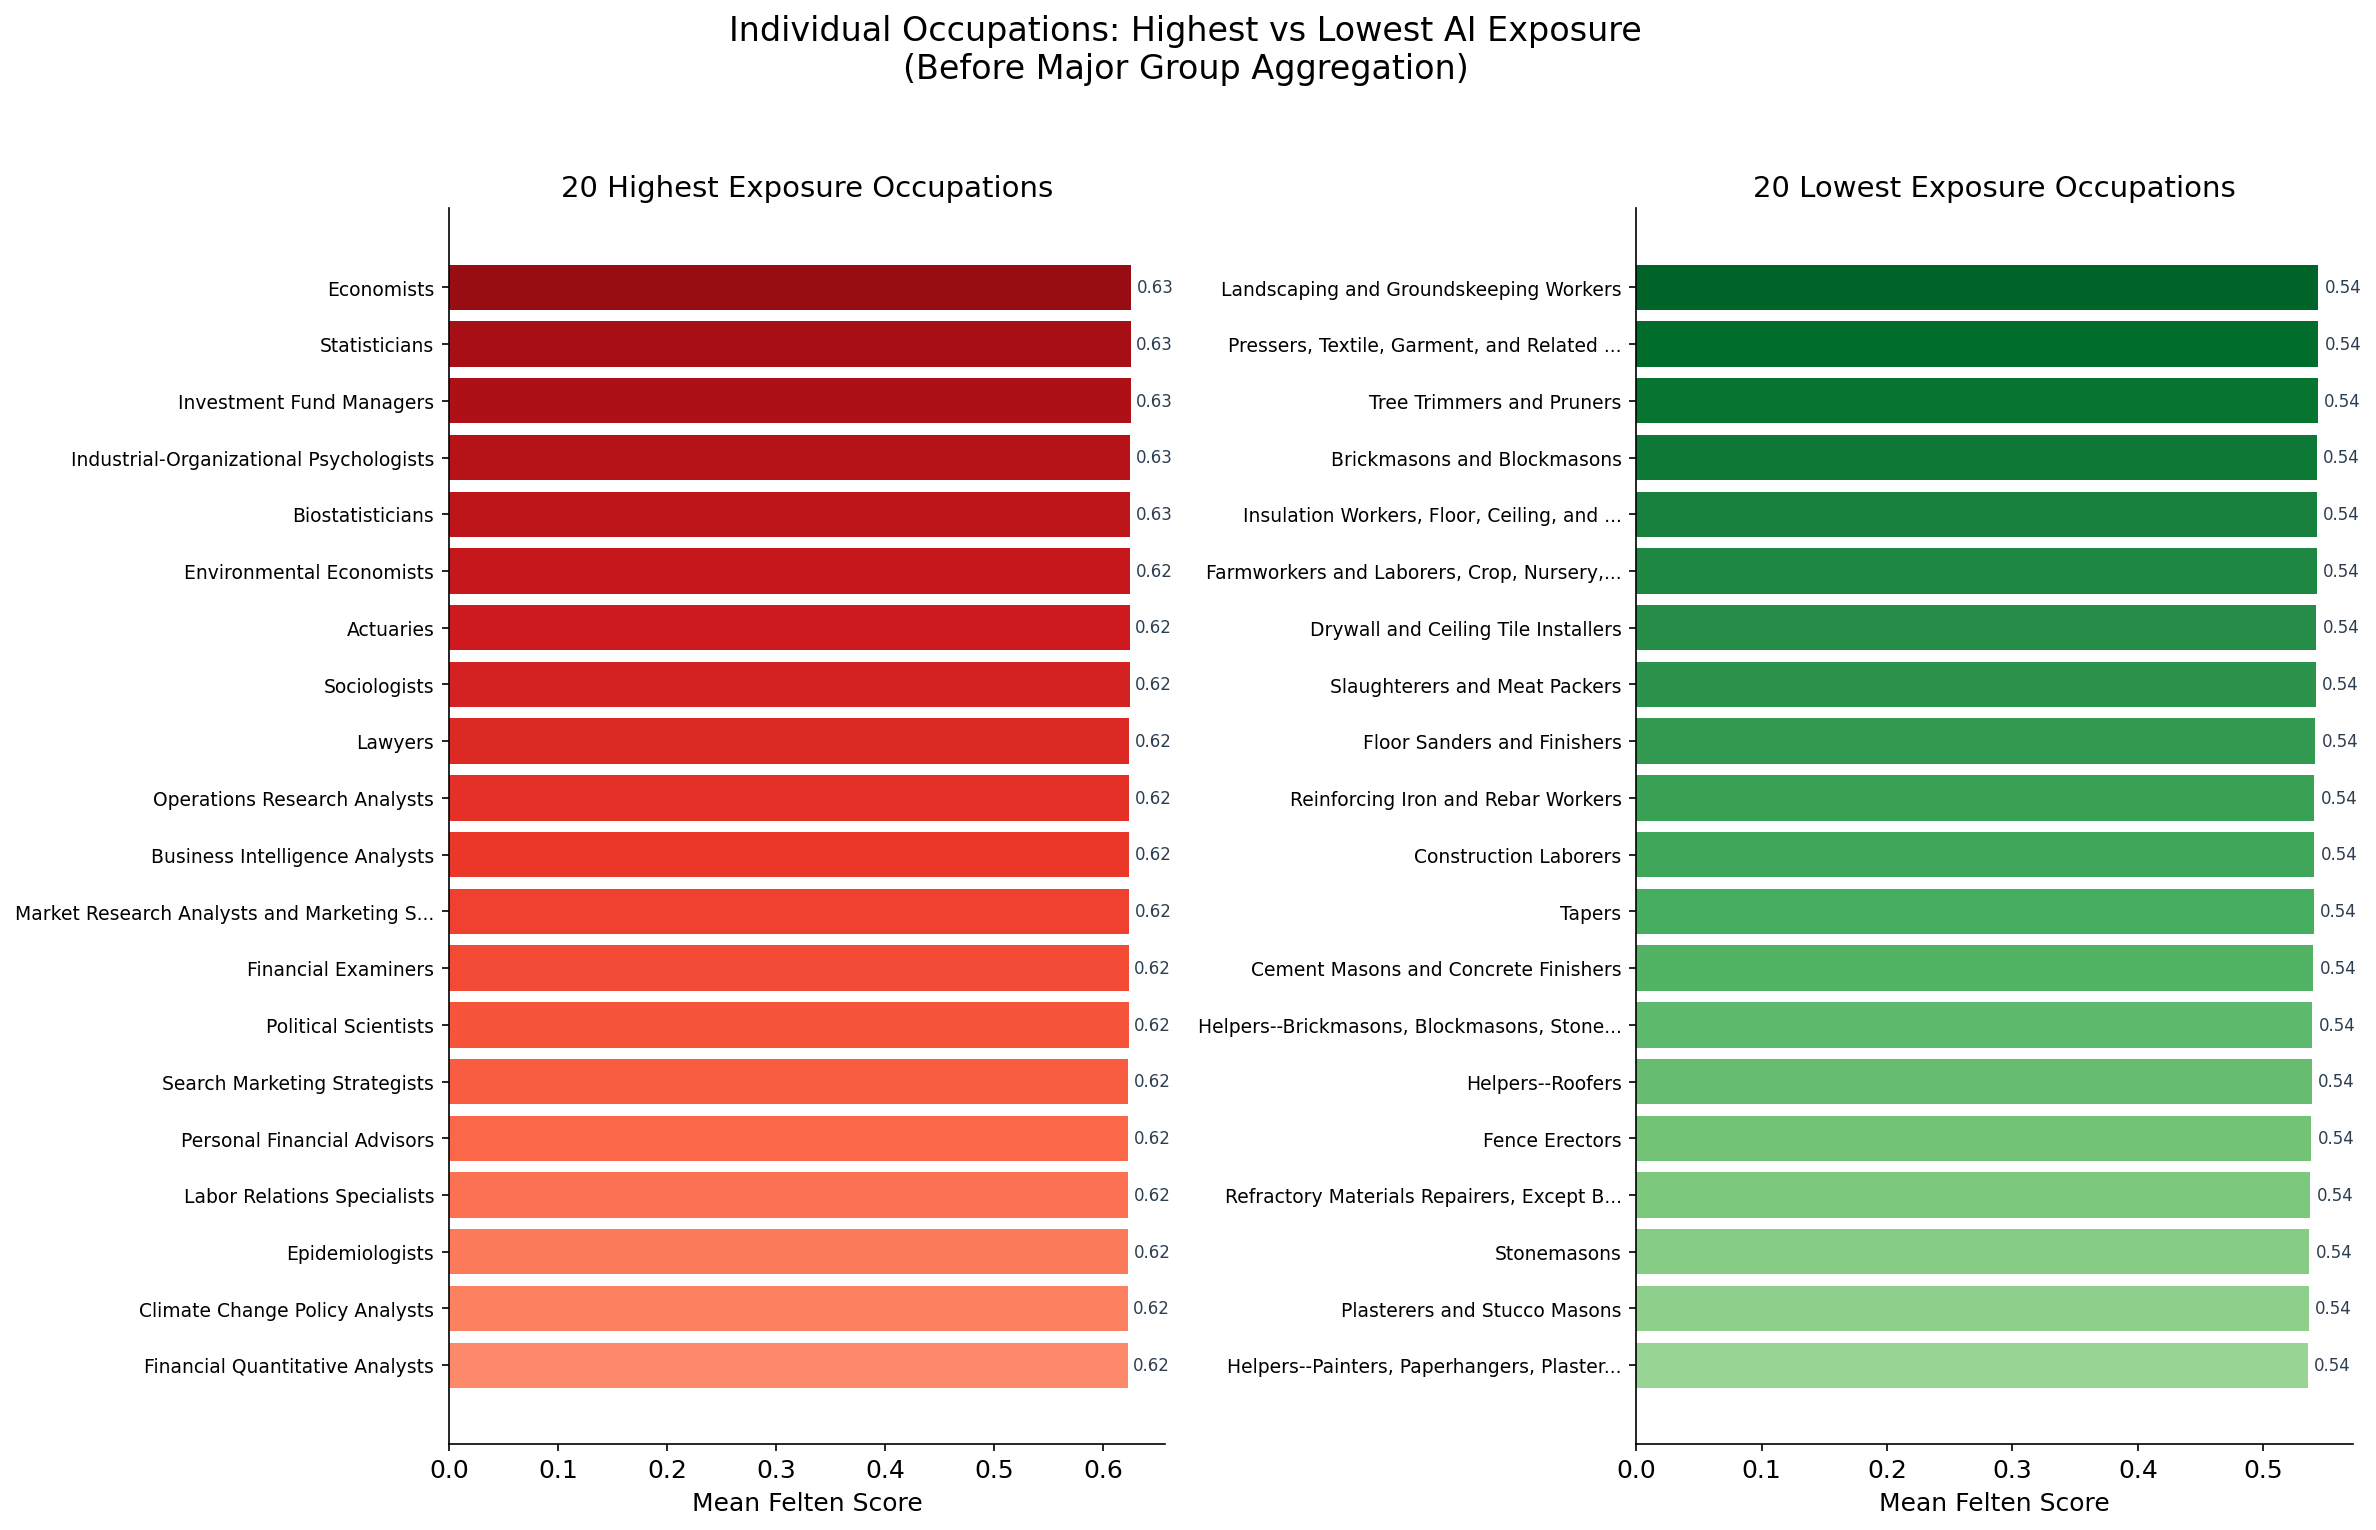

Saved: outputs/slides_mvp/tables/all_occupations_felten_scores.csv


In [ ]:
# =============================================================================
# H.3b TOP INDIVIDUAL OCCUPATIONS (GRANULAR VIEW)
# =============================================================================
# Before aggregating to major groups, let's see which specific occupations
# have the highest/lowest exposure scores in the job ads data.

print("=== TOP OCCUPATIONS BY EXPOSURE SCORES (Granular Level) ===\n")

if 'dominant_occupation' in df.columns and len(occ_level_stats) > 0:
    felten_col = 'felten_score_mean'
    
    if felten_col in occ_level_stats.columns:
        # --- TOP 15 HIGHEST EXPOSURE OCCUPATIONS ---
        print("### Top 15 Occupations with HIGHEST Felten AI Exposure:")
        top_exp = occ_level_stats.nlargest(15, felten_col)
        for i, (_, row) in enumerate(top_exp.iterrows(), 1):
            print(f"  {i:>2}. {row[felten_col]:.3f} - {row['group_name']} (n={row['n_jobs']:,})")
        
        # --- TOP 15 LOWEST EXPOSURE OCCUPATIONS ---
        print("\n### Top 15 Occupations with LOWEST Felten AI Exposure:")
        low_exp = occ_level_stats.nsmallest(15, felten_col)
        for i, (_, row) in enumerate(low_exp.iterrows(), 1):
            print(f"  {i:>2}. {row[felten_col]:.3f} - {row['group_name']} (n={row['n_jobs']:,})")
        
        # --- VISUALIZATION: Top & Bottom 20 Occupations ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 10))
        
        # Left: Highest exposure
        ax1 = axes[0]
        top_20 = occ_level_stats.nlargest(20, felten_col)
        colors_top = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_20)))
        ax1.barh(range(len(top_20)), top_20[felten_col], color=colors_top[::-1])
        ax1.set_yticks(range(len(top_20)))
        ax1.set_yticklabels([g[:40] + '...' if len(str(g)) > 40 else g 
                             for g in top_20['group_name']], fontsize=9)
        ax1.set_xlabel('Mean Felten Score', fontsize=12)
        ax1.set_title('20 Highest Exposure Occupations', fontsize=14)
        ax1.invert_yaxis()
        for i, (_, row) in enumerate(top_20.iterrows()):
            ax1.text(row[felten_col] + 0.005, i, f'{row[felten_col]:.2f}', 
                     va='center', fontsize=8, color=PRIMARY_COLOR)
        
        # Right: Lowest exposure
        ax2 = axes[1]
        bottom_20 = occ_level_stats.nsmallest(20, felten_col)
        colors_bot = plt.cm.Greens(np.linspace(0.4, 0.9, len(bottom_20)))
        ax2.barh(range(len(bottom_20)), bottom_20[felten_col], color=colors_bot)
        ax2.set_yticks(range(len(bottom_20)))
        ax2.set_yticklabels([g[:40] + '...' if len(str(g)) > 40 else g 
                             for g in bottom_20['group_name']], fontsize=9)
        ax2.set_xlabel('Mean Felten Score', fontsize=12)
        ax2.set_title('20 Lowest Exposure Occupations', fontsize=14)
        for i, (_, row) in enumerate(bottom_20.iterrows()):
            ax2.text(row[felten_col] + 0.005, i, f'{row[felten_col]:.2f}', 
                     va='center', fontsize=8, color=PRIMARY_COLOR)
        
        plt.suptitle('Individual Occupations: Highest vs Lowest AI Exposure\n(Before Major Group Aggregation)', 
                     fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(OUT_FIG / "top_bottom_occupations_granular.png", dpi=300, bbox_inches='tight')
        print(f"\nSaved: {OUT_FIG / 'top_bottom_occupations_granular.png'}")
        plt.show()
        
        # Save detailed table
        occ_level_stats_out = occ_level_stats[['group_name', felten_col, 'n_jobs']].copy()
        occ_level_stats_out.columns = ['Occupation', 'Mean Felten Score', 'N Jobs']
        occ_level_stats_out.to_csv(OUT_TAB / "all_occupations_felten_scores.csv", index=False)
        print(f"Saved: {OUT_TAB / 'all_occupations_felten_scores.csv'}")
    else:
        print(f"felten_score_mean not in occ_level_stats columns: {occ_level_stats.columns.tolist()}")
else:
    print("Occupation-level stats not available")

Saved: outputs/slides_mvp/figures/task_vs_humanness_by_onet_major.png
Saved: outputs/slides_mvp/tables/task_humanness_by_onet_major.csv


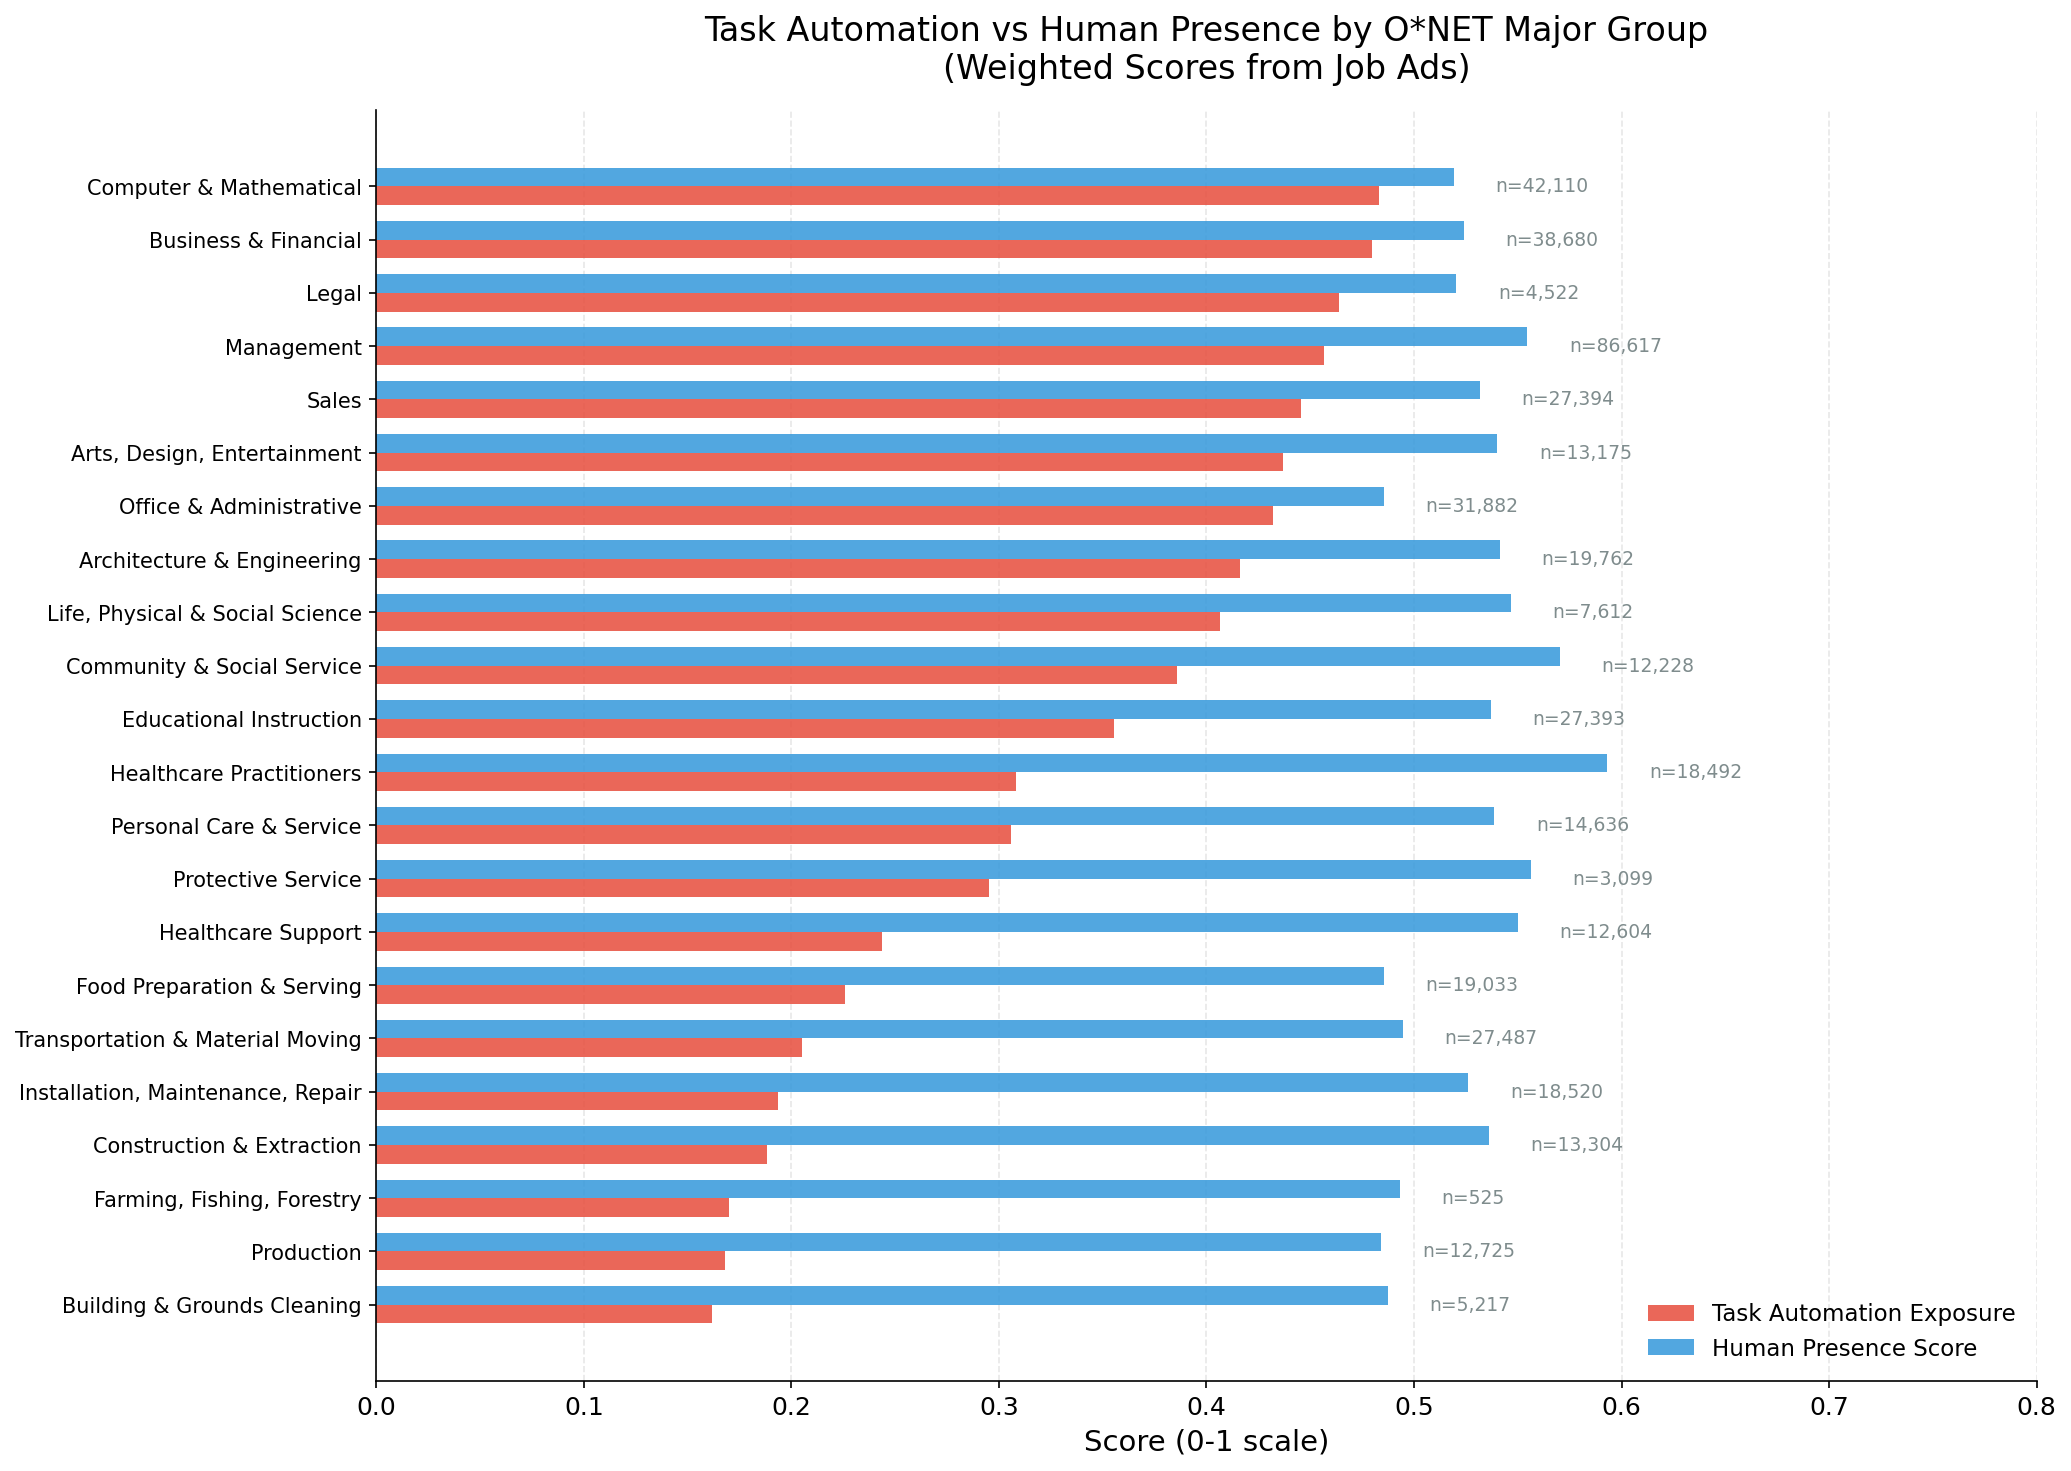


### O*NET Major Groups by Task Automation Potential
                O*NET Major Group  Task Automation  Human Presence  Felten Exposure  N Jobs
          Computer & Mathematical            0.483           0.519            0.615   42110
             Business & Financial            0.480           0.524            0.616   38680
                            Legal            0.464           0.520            0.621    4522
                       Management            0.457           0.555            0.608   86617
                            Sales            0.446           0.532            0.605   27394
      Arts, Design, Entertainment            0.437           0.540            0.606   13175
          Office & Administrative            0.432           0.486            0.599   31882
       Architecture & Engineering            0.416           0.541            0.603   19762
  Life, Physical & Social Science            0.406           0.547            0.606    7612
       Community & Social S

In [ ]:
# =============================================================================
# H.4 TASK AUTOMATION vs HUMAN PRESENCE BY O*NET MAJOR GROUP
# =============================================================================

if HAS_MULTI_SCORES and 'onet_major' in df.columns:
    # Aggregate by O*NET major group (using already-calculated weighted scores)
    task_by_onet = df.dropna(subset=['task_exposure_score', 'onet_major']).groupby('onet_major').agg(
        n_jobs=('task_exposure_score', 'count'),
        task_exposure_mean=('task_exposure_score', 'mean'),
        humanness_mean=('humanness_score', 'mean'),
        felten_mean=('felten_score', 'mean')
    ).reset_index()
    
    # Add names
    task_by_onet['group_name'] = task_by_onet['onet_major'].map(ONET_MAJOR_NAMES)
    task_by_onet = task_by_onet.dropna(subset=['group_name'])
    task_by_onet = task_by_onet.sort_values('task_exposure_mean', ascending=True)
    
    # Create dual-metric chart: Task Exposure vs Humanness
    fig, ax = plt.subplots(figsize=(14, 10))
    
    y_pos = np.arange(len(task_by_onet))
    bar_height = 0.35
    
    # Task exposure bars (automation potential)
    bars1 = ax.barh(y_pos - bar_height/2, task_by_onet['task_exposure_mean'], 
                    bar_height, color=ACCENT_COLOR, alpha=0.85, label='Task Automation Exposure')
    
    # Humanness bars (human presence requirement)
    bars2 = ax.barh(y_pos + bar_height/2, task_by_onet['humanness_mean'], 
                    bar_height, color=SECONDARY_COLOR, alpha=0.85, label='Human Presence Score')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(task_by_onet['group_name'], fontsize=10)
    ax.set_xlabel('Score (0-1 scale)', fontsize=14)
    ax.set_title('Task Automation vs Human Presence by O*NET Major Group\n(Weighted Scores from Job Ads)', 
                 fontsize=16, pad=15)
    ax.legend(loc='lower right', fontsize=11, frameon=False)
    
    # Add job count annotations
    for i, (_, row) in enumerate(task_by_onet.iterrows()):
        ax.text(max(row['task_exposure_mean'], row['humanness_mean']) + 0.02, i, 
                f"n={int(row['n_jobs']):,}", va='center', fontsize=9, color=GREY_MED)
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xlim(0, 0.8)
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "task_vs_humanness_by_onet_major.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {OUT_FIG / 'task_vs_humanness_by_onet_major.png'}")
    
    # Save table
    task_by_onet_out = task_by_onet[['group_name', 'task_exposure_mean', 'humanness_mean', 
                                      'felten_mean', 'n_jobs']].copy()
    task_by_onet_out.columns = ['O*NET Major Group', 'Task Automation', 'Human Presence', 
                                 'Felten Exposure', 'N Jobs']
    task_by_onet_out = task_by_onet_out.round(3)
    task_by_onet_out.to_csv(OUT_TAB / "task_humanness_by_onet_major.csv", index=False)
    print(f"Saved: {OUT_TAB / 'task_humanness_by_onet_major.csv'}")
    
    plt.show()
    
    print("\n### O*NET Major Groups by Task Automation Potential")
    print(task_by_onet_out.sort_values('Task Automation', ascending=False).to_string(index=False))
else:
    print("Skipping - multi-scores or onet_major not available")

365 LADs with n >= 50 jobs

Saved: outputs/slides_mvp/tables/lads_by_task_automation.csv

### LADs with HIGHEST Task Automation Potential
       LAD22NM  task_exposure_mean  humanness_mean  n_jobs
City of London            0.456484        0.529458    5553
       Belfast            0.436059        0.526495    2255
   Westminster            0.433897        0.529572    9904
     Islington            0.430144        0.537318    1456
 Malvern Hills            0.425923        0.532931     487
       Hackney            0.419554        0.534701    1243
    Manchester            0.417908        0.530628   12389
Waltham Forest            0.412984        0.535108    1248
         Leeds            0.403220        0.531540    5220
  Glasgow City            0.402550        0.531014    4046

### LADs with LOWEST Task Automation Potential (more human-dependent)
         LAD22NM  task_exposure_mean  humanness_mean  n_jobs
         Fenland            0.272135        0.522040     191
South Derbyshire    

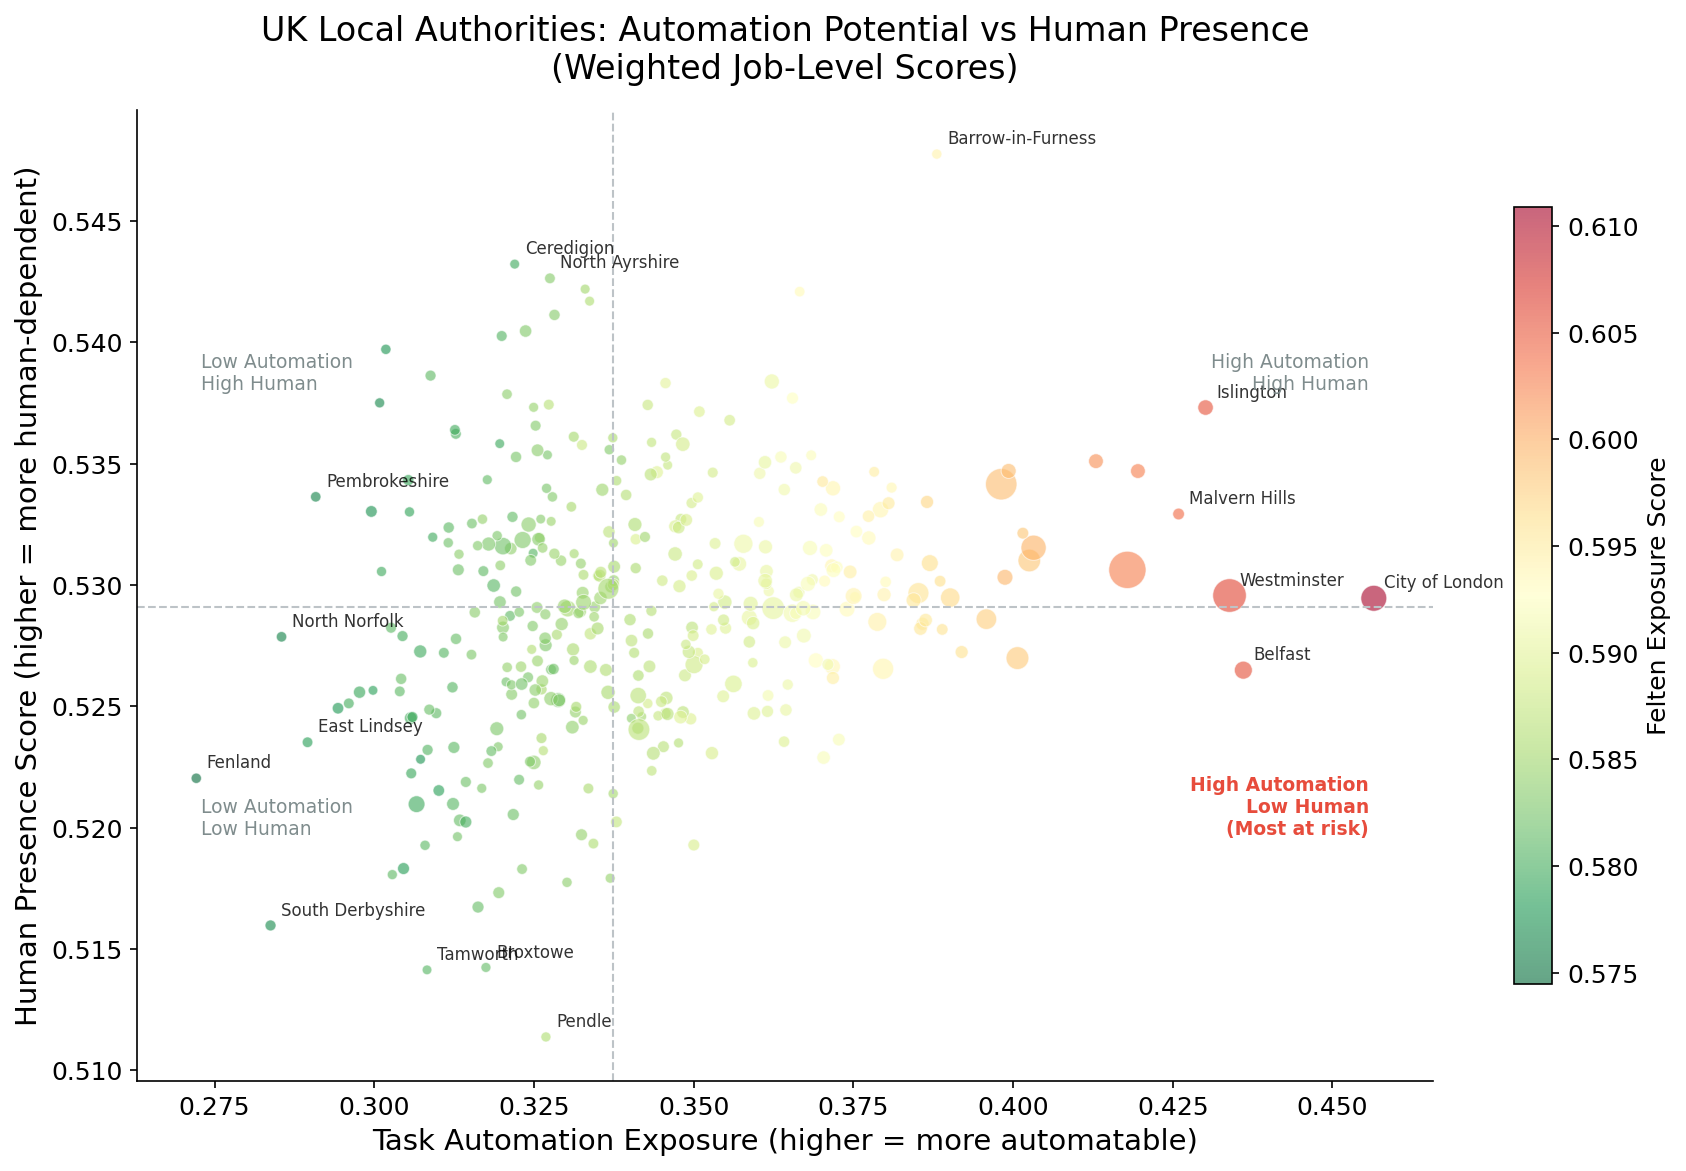

In [ ]:
# =============================================================================
# H.5 TASK AUTOMATION & HUMAN PRESENCE BY GEOGRAPHY (LAD)
# =============================================================================

if HAS_MULTI_SCORES and GEO_COL:
    # Aggregate by LAD using pre-computed weighted scores
    geo_multi_scores = df.dropna(subset=['task_exposure_score', GEO_COL]).groupby(GEO_COL).agg(
        n_jobs=('task_exposure_score', 'count'),
        task_exposure_mean=('task_exposure_score', 'mean'),
        humanness_mean=('humanness_score', 'mean'),
        physical_mean=('physical_presence', 'mean'),
        emotional_mean=('emotional_presence', 'mean'),
        creative_mean=('creative_presence', 'mean'),
        felten_mean=('felten_score', 'mean')
    ).reset_index()
    
    # Filter by minimum sample size
    geo_multi_filtered = geo_multi_scores[geo_multi_scores['n_jobs'] >= MIN_N].copy()
    print(f"{len(geo_multi_filtered)} LADs with n >= {MIN_N} jobs")
    
    # === TOP/BOTTOM LADs BY TASK AUTOMATION ===
    task_top = geo_multi_filtered.nlargest(10, 'task_exposure_mean').copy()
    task_top['rank_type'] = 'Top 10 (Highest Automation Potential)'
    task_bottom = geo_multi_filtered.nsmallest(10, 'task_exposure_mean').copy()
    task_bottom['rank_type'] = 'Bottom 10 (Lowest Automation Potential)'
    
    task_lads = pd.concat([task_top, task_bottom])
    task_lads.to_csv(OUT_TAB / "lads_by_task_automation.csv", index=False)
    print(f"\nSaved: {OUT_TAB / 'lads_by_task_automation.csv'}")
    
    print("\n### LADs with HIGHEST Task Automation Potential")
    print(task_top[[GEO_COL, 'task_exposure_mean', 'humanness_mean', 'n_jobs']].to_string(index=False))
    
    print("\n### LADs with LOWEST Task Automation Potential (more human-dependent)")
    print(task_bottom[[GEO_COL, 'task_exposure_mean', 'humanness_mean', 'n_jobs']].to_string(index=False))
    
    # === SCATTER PLOT: AUTOMATION VS HUMANNESS BY LAD ===
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Size points by job count
    sizes = geo_multi_filtered['n_jobs'] / geo_multi_filtered['n_jobs'].max() * 300 + 20
    
    scatter = ax.scatter(
        geo_multi_filtered['task_exposure_mean'],
        geo_multi_filtered['humanness_mean'],
        s=sizes,
        c=geo_multi_filtered['felten_mean'],
        cmap='RdYlGn_r',
        alpha=0.6,
        edgecolor='white',
        linewidth=0.5
    )
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Felten Exposure Score', fontsize=12)
    
    # Label extreme points
    extremes = pd.concat([
        geo_multi_filtered.nlargest(5, 'task_exposure_mean'),
        geo_multi_filtered.nsmallest(5, 'task_exposure_mean'),
        geo_multi_filtered.nlargest(3, 'humanness_mean'),
        geo_multi_filtered.nsmallest(3, 'humanness_mean')
    ]).drop_duplicates()
    
    for _, row in extremes.iterrows():
        ax.annotate(
            row[GEO_COL],
            xy=(row['task_exposure_mean'], row['humanness_mean']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8, alpha=0.8
        )
    
    ax.set_xlabel('Task Automation Exposure (higher = more automatable)', fontsize=14)
    ax.set_ylabel('Human Presence Score (higher = more human-dependent)', fontsize=14)
    ax.set_title('UK Local Authorities: Automation Potential vs Human Presence\n(Weighted Job-Level Scores)', 
                 fontsize=16, pad=15)
    
    # Add quadrant lines at medians
    median_task = geo_multi_filtered['task_exposure_mean'].median()
    median_human = geo_multi_filtered['humanness_mean'].median()
    ax.axvline(median_task, color=GREY_LIGHT, linestyle='--', linewidth=1)
    ax.axhline(median_human, color=GREY_LIGHT, linestyle='--', linewidth=1)
    
    # Quadrant labels
    ax.text(ax.get_xlim()[0] + 0.01, ax.get_ylim()[1] - 0.01, 
            'Low Automation\nHigh Human', fontsize=9, color=GREY_MED, va='top', ha='left')
    ax.text(ax.get_xlim()[1] - 0.01, ax.get_ylim()[1] - 0.01, 
            'High Automation\nHigh Human', fontsize=9, color=GREY_MED, va='top', ha='right')
    ax.text(ax.get_xlim()[0] + 0.01, ax.get_ylim()[0] + 0.01, 
            'Low Automation\nLow Human', fontsize=9, color=GREY_MED, va='bottom', ha='left')
    ax.text(ax.get_xlim()[1] - 0.01, ax.get_ylim()[0] + 0.01, 
            'High Automation\nLow Human\n(Most at risk)', fontsize=9, color=ACCENT_COLOR, 
            va='bottom', ha='right', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "lad_automation_vs_humanness_scatter.png", dpi=300, bbox_inches='tight')
    print(f"\nSaved: {OUT_FIG / 'lad_automation_vs_humanness_scatter.png'}")
    plt.show()
else:
    print("Skipping geographic multi-score analysis - missing data")

Saved: outputs/slides_mvp/figures/human_presence_by_onet_major.png
Saved: outputs/slides_mvp/tables/human_presence_by_onet_major.csv


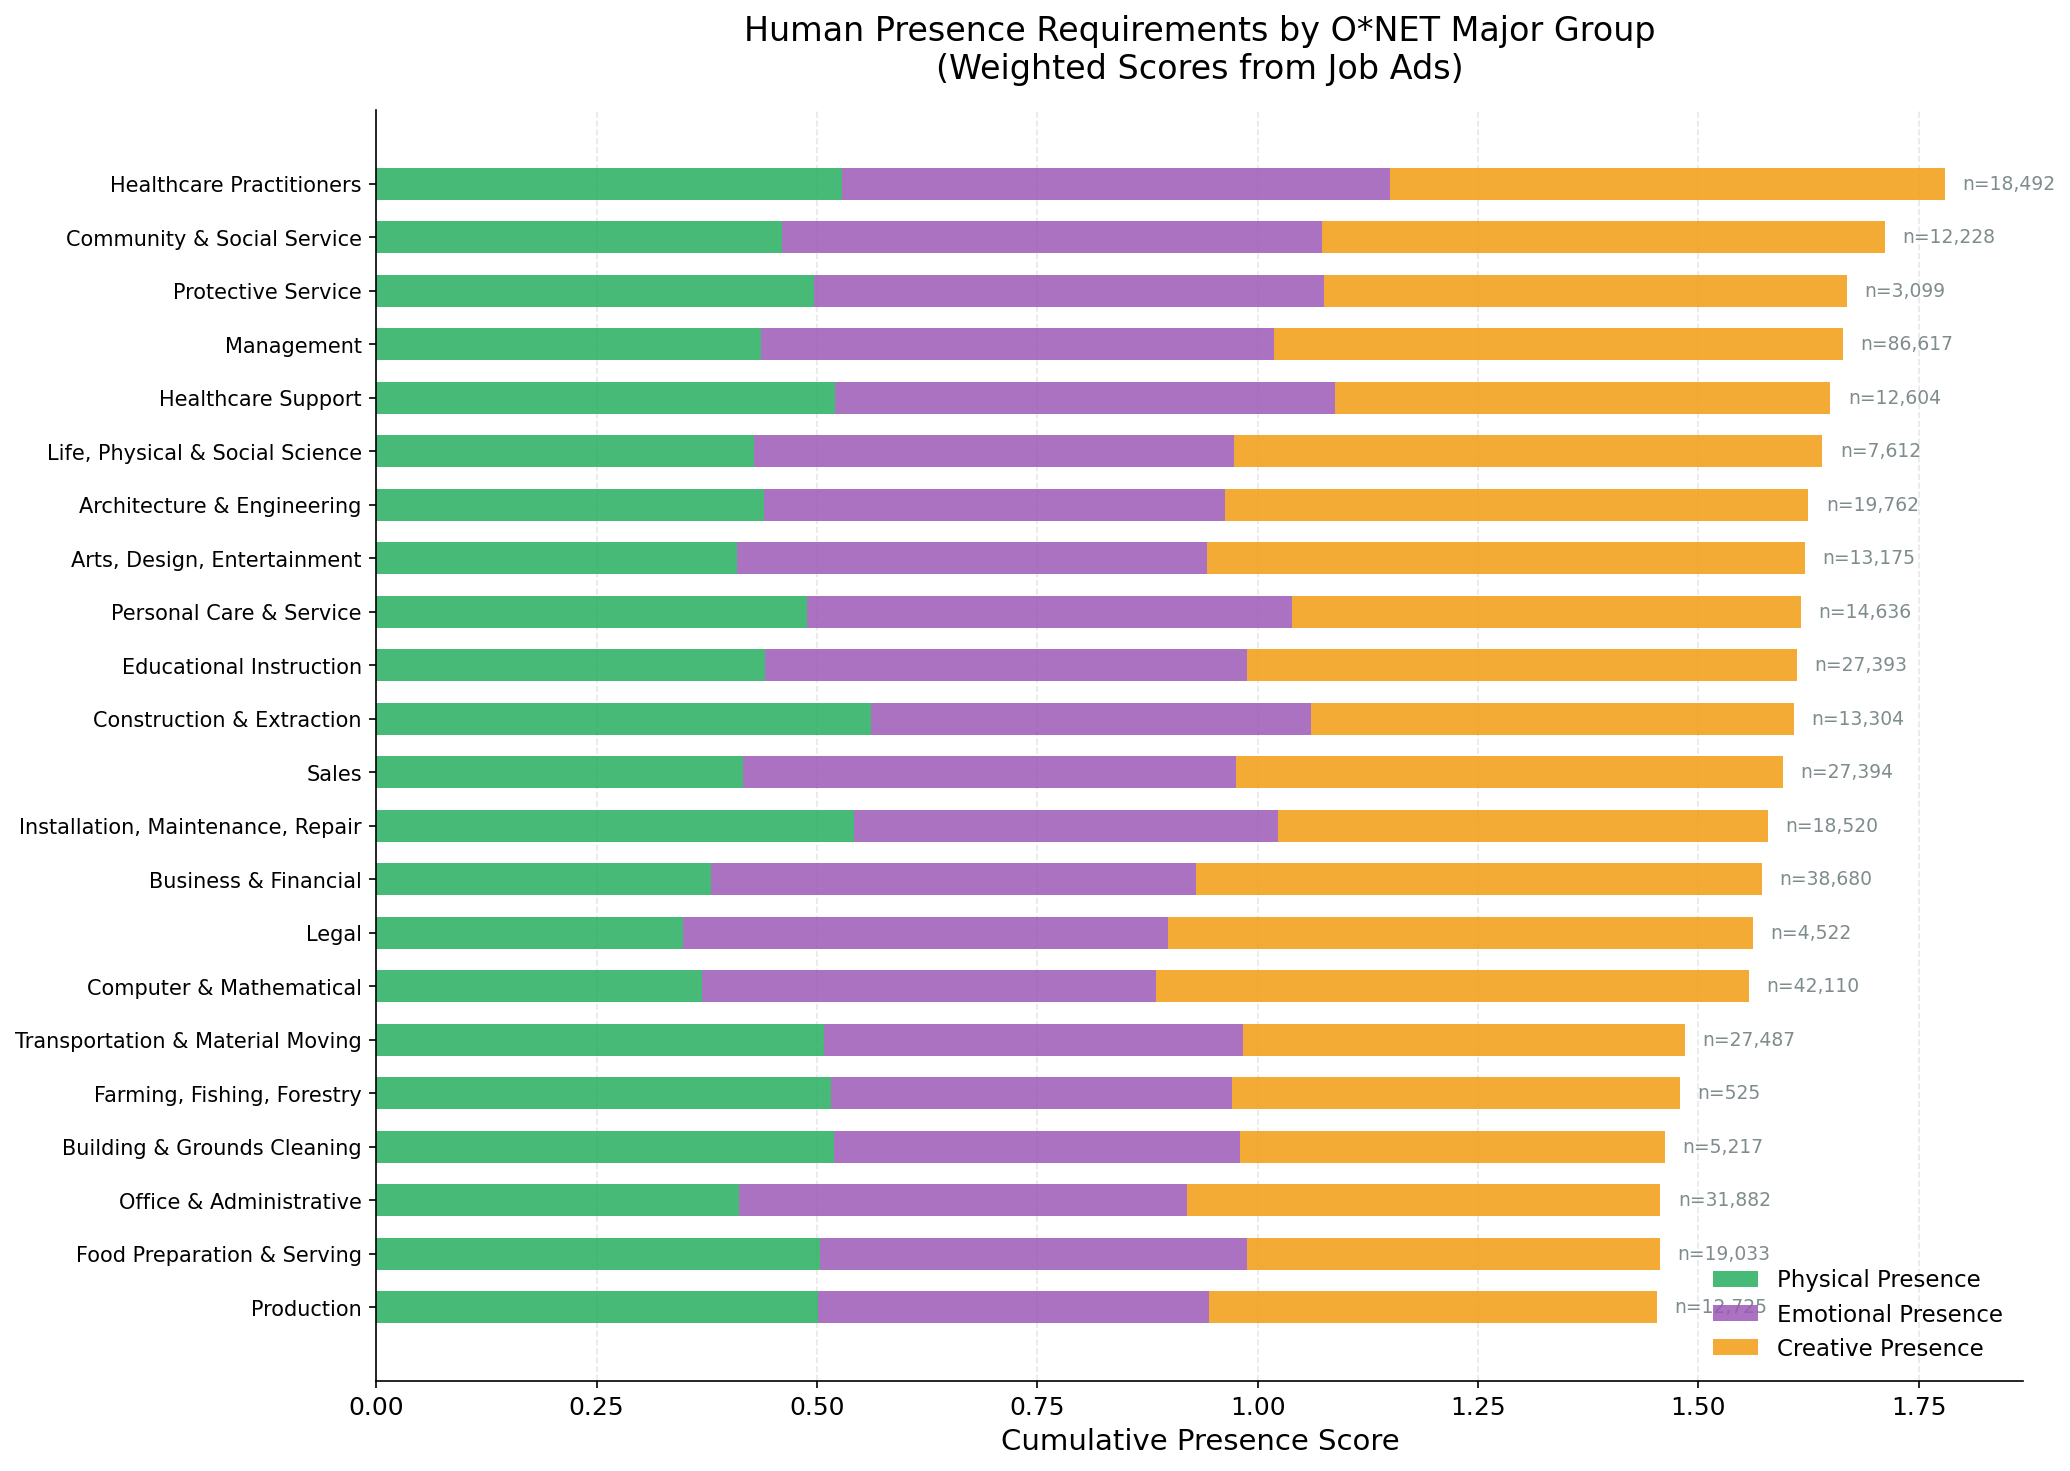


### O*NET Major Groups by Human Presence Requirements (sorted by total)
                O*NET Major Group  Physical  Emotional  Creative  Total Humanness  N Jobs
         Healthcare Practitioners     0.529      0.621     0.630            0.593   18492
       Community & Social Service     0.460      0.613     0.638            0.570   12228
               Protective Service     0.497      0.578     0.593            0.556    3099
                       Management     0.437      0.582     0.645            0.555   86617
               Healthcare Support     0.520      0.567     0.563            0.550   12604
  Life, Physical & Social Science     0.428      0.545     0.667            0.547    7612
       Architecture & Engineering     0.439      0.523     0.662            0.541   19762
      Arts, Design, Entertainment     0.410      0.533     0.678            0.540   13175
          Personal Care & Service     0.488      0.551     0.577            0.539   14636
          Educational Instr

In [ ]:
# =============================================================================
# H.6 HUMAN PRESENCE BREAKDOWN: PHYSICAL, EMOTIONAL, CREATIVE
# =============================================================================

if HAS_MULTI_SCORES and 'onet_major' in df.columns:
    # Aggregate presence types by O*NET major group (using weighted scores)
    presence_by_onet = df.dropna(subset=['physical_presence', 'onet_major']).groupby('onet_major').agg(
        n_jobs=('physical_presence', 'count'),
        physical=('physical_presence', 'mean'),
        emotional=('emotional_presence', 'mean'),
        creative=('creative_presence', 'mean'),
        humanness_total=('humanness_score', 'mean')
    ).reset_index()
    
    presence_by_onet['group_name'] = presence_by_onet['onet_major'].map(ONET_MAJOR_NAMES)
    presence_by_onet = presence_by_onet.dropna(subset=['group_name'])
    presence_by_onet = presence_by_onet.sort_values('humanness_total', ascending=True)
    
    # Stacked horizontal bar chart for presence types
    fig, ax = plt.subplots(figsize=(14, 10))
    
    y_pos = np.arange(len(presence_by_onet))
    
    # Stacked bars for each presence type
    physical_bars = ax.barh(y_pos, presence_by_onet['physical'], 
                            height=0.6, color='#27AE60', alpha=0.85, label='Physical Presence')
    emotional_bars = ax.barh(y_pos, presence_by_onet['emotional'], 
                             height=0.6, left=presence_by_onet['physical'],
                             color='#9B59B6', alpha=0.85, label='Emotional Presence')
    creative_bars = ax.barh(y_pos, presence_by_onet['creative'], 
                            height=0.6, left=presence_by_onet['physical'] + presence_by_onet['emotional'],
                            color='#F39C12', alpha=0.85, label='Creative Presence')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(presence_by_onet['group_name'], fontsize=10)
    ax.set_xlabel('Cumulative Presence Score', fontsize=14)
    ax.set_title('Human Presence Requirements by O*NET Major Group\n(Weighted Scores from Job Ads)', 
                 fontsize=16, pad=15)
    ax.legend(loc='lower right', fontsize=11, frameon=False)
    
    # Add total humanness label
    for i, (_, row) in enumerate(presence_by_onet.iterrows()):
        total = row['physical'] + row['emotional'] + row['creative']
        ax.text(total + 0.02, i, f"n={int(row['n_jobs']):,}", 
                va='center', fontsize=9, color=GREY_MED)
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "human_presence_by_onet_major.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {OUT_FIG / 'human_presence_by_onet_major.png'}")
    
    # Save table
    presence_out = presence_by_onet[['group_name', 'physical', 'emotional', 'creative', 
                                      'humanness_total', 'n_jobs']].copy()
    presence_out.columns = ['O*NET Major Group', 'Physical', 'Emotional', 'Creative', 
                            'Total Humanness', 'N Jobs']
    presence_out = presence_out.round(3)
    presence_out.to_csv(OUT_TAB / "human_presence_by_onet_major.csv", index=False)
    print(f"Saved: {OUT_TAB / 'human_presence_by_onet_major.csv'}")
    
    plt.show()
    
    print("\n### O*NET Major Groups by Human Presence Requirements (sorted by total)")
    print(presence_out.sort_values('Total Humanness', ascending=False).to_string(index=False))
else:
    print("Skipping - multi-scores or onet_major not available")

Saved: outputs/slides_mvp/figures/occupation_task_vs_humanness_scatter.png


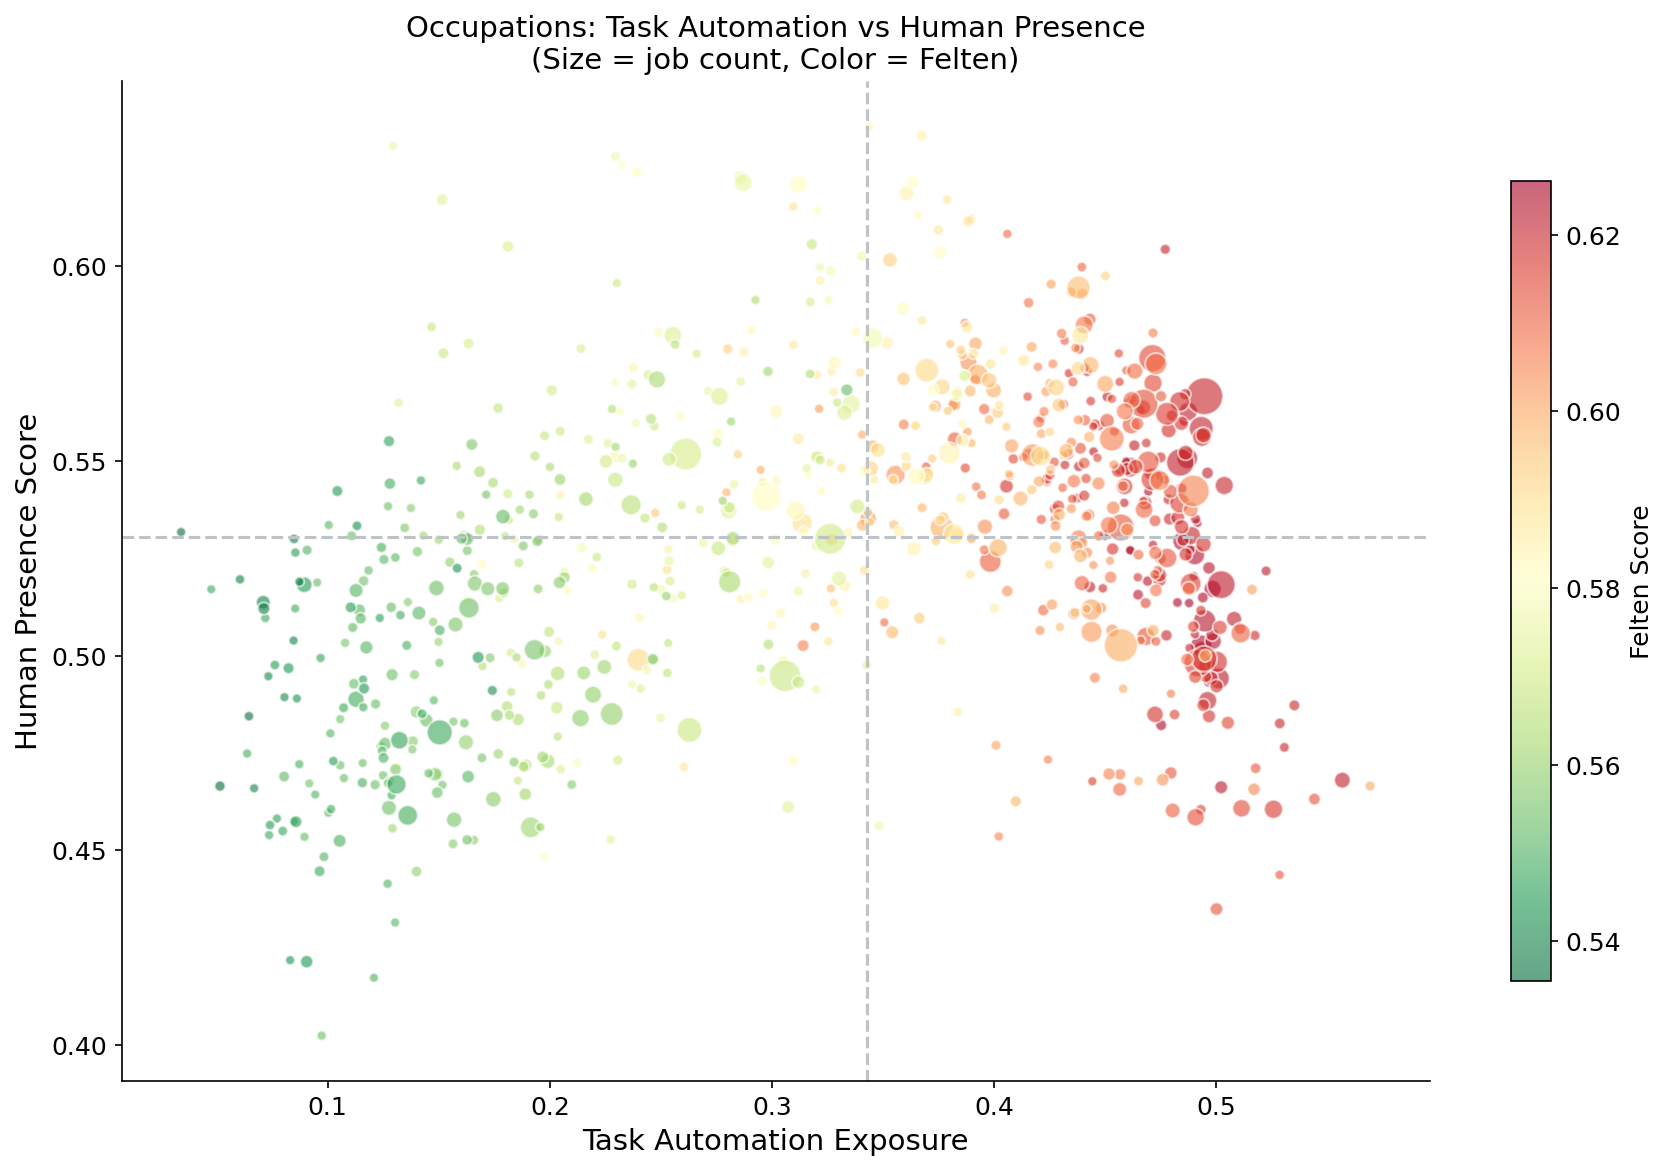

In [ ]:
# =============================================================================
# H.7 ADDITIONAL VISUALIZATIONS
# =============================================================================

# Scatter: Task Exposure vs Humanness at occupation level
if HAS_MULTI_SCORES and 'task_exposure_norm' in df.columns:
    # Aggregate at occupation level with multiple scores
    occ_multi = aggregate_scores(
        df, 
        group_col='dominant_occupation',
        score_cols=['felten_score', 'task_exposure_norm', 'humanness_avg'],
        min_n=20
    )
    
    if len(occ_multi) > 10 and 'task_exposure_norm_mean' in occ_multi.columns and 'humanness_avg_mean' in occ_multi.columns:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        scatter = ax.scatter(
            occ_multi['task_exposure_norm_mean'],
            occ_multi['humanness_avg_mean'],
            s=occ_multi['n_jobs'] / occ_multi['n_jobs'].max() * 300 + 20,
            c=occ_multi['felten_score_mean'] if 'felten_score_mean' in occ_multi.columns else 'blue',
            cmap='RdYlGn_r',
            alpha=0.6,
            edgecolor='white'
        )
        
        if 'felten_score_mean' in occ_multi.columns:
            cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
            cbar.set_label('Felten Score', fontsize=12)
        
        ax.set_xlabel('Task Automation Exposure', fontsize=14)
        ax.set_ylabel('Human Presence Score', fontsize=14)
        ax.set_title('Occupations: Task Automation vs Human Presence\n(Size = job count, Color = Felten)', 
                     fontsize=14)
        
        # Add quadrant lines
        ax.axvline(occ_multi['task_exposure_norm_mean'].median(), color=GREY_LIGHT, linestyle='--')
        ax.axhline(occ_multi['humanness_avg_mean'].median(), color=GREY_LIGHT, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(OUT_FIG / "occupation_task_vs_humanness_scatter.png", dpi=300, bbox_inches='tight')
        print(f"Saved: {OUT_FIG / 'occupation_task_vs_humanness_scatter.png'}")
        plt.show()
    else:
        print("Not enough data for scatter plot")
else:
    print("Skipping scatter - multi-scores not available")

SUMMARY: HUMAN-CENTERED vs AUTOMATION-EXPOSED AREAS

### Top 15 LADs with Most Human-Dependent Jobs
(High physical, emotional, or creative presence required)
                    LAD  Human Presence  Task Automation  N Jobs
      Barrow-in-Furness           0.548            0.388     167
             Ceredigion           0.543            0.322      97
         North Ayrshire           0.543            0.328     266
Derry City and Strabane           0.542            0.333      98
               Copeland           0.542            0.367     231
             Inverclyde           0.542            0.334     102
          Isle of Wight           0.541            0.328     385
          Aberdeenshire           0.540            0.324     645
        Argyll and Bute           0.540            0.320     296
    West Dunbartonshire           0.540            0.302     181
        Carmarthenshire           0.539            0.309     318
          Aberdeen City           0.538            0.362    13

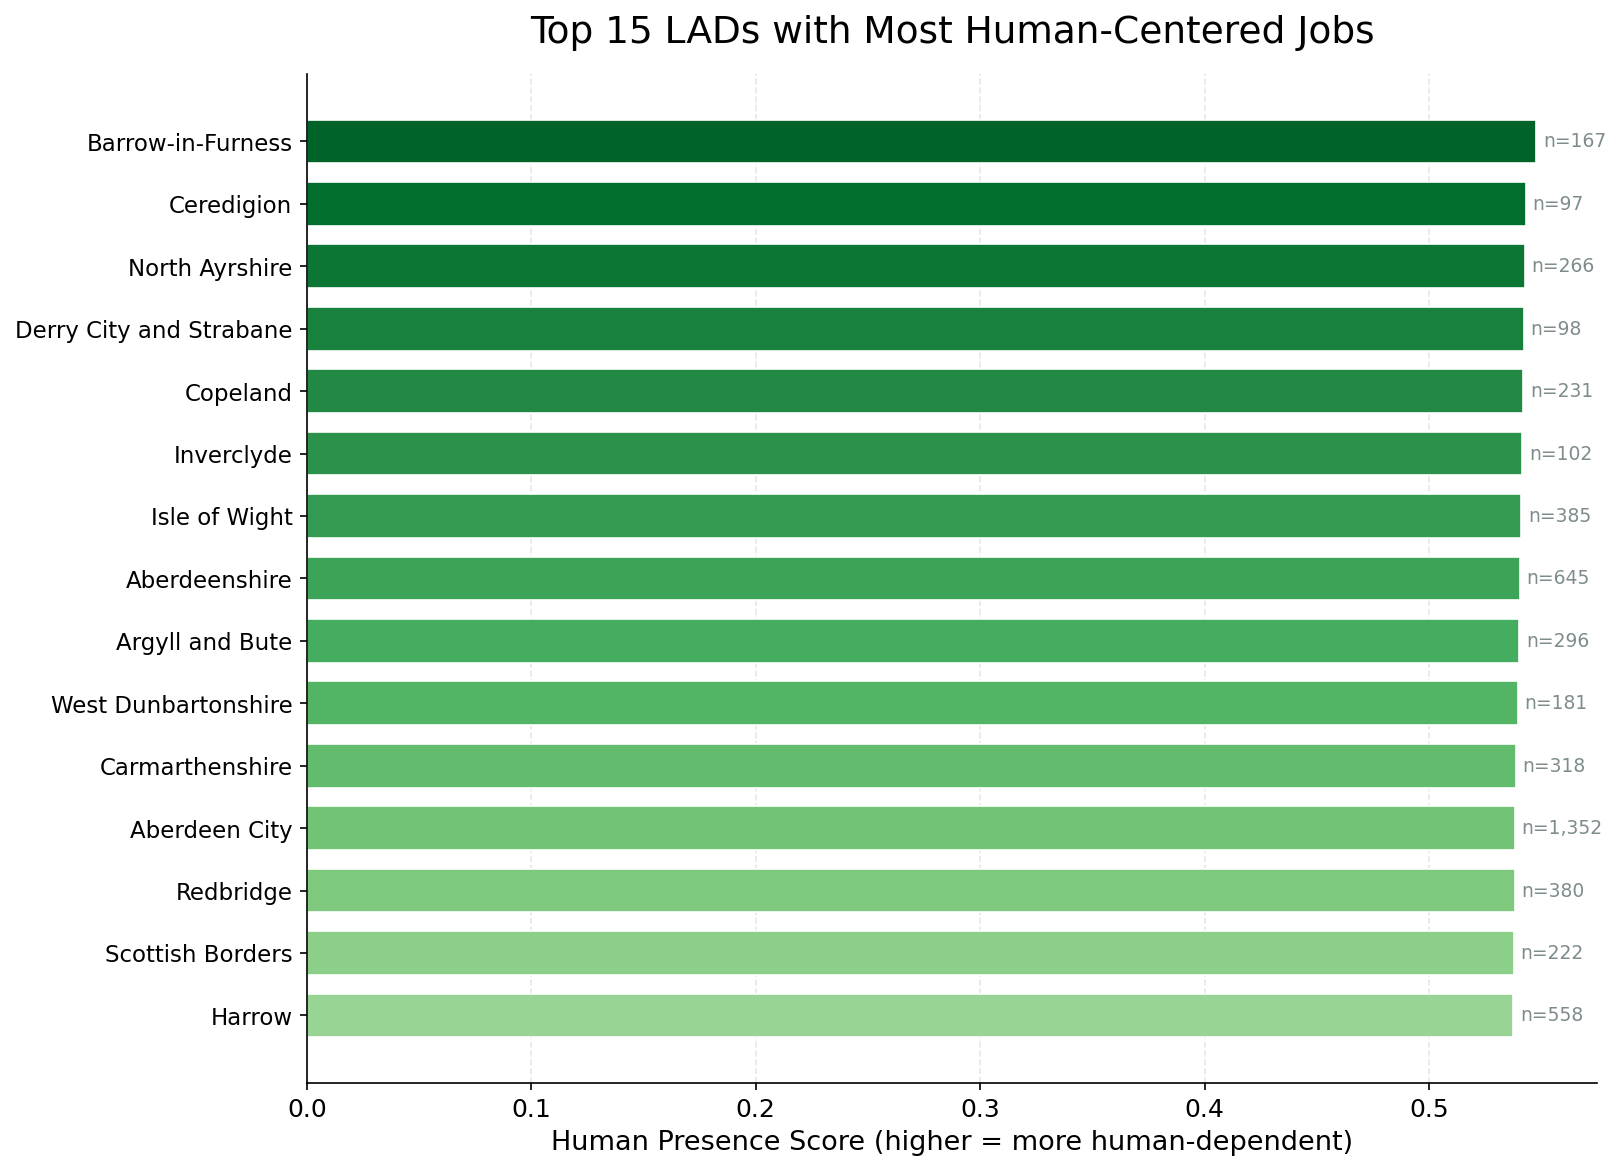


### London vs Rest of UK: Human Presence
    Region  humanness_mean  task_mean      n
Rest of UK           0.530      0.373 419248
    London           0.531      0.399  37769


In [ ]:
# =============================================================================
# H.8 SUMMARY: WHERE ARE THE MOST "HUMAN" JOBS?
# =============================================================================

if HAS_MULTI_SCORES and GEO_COL:
    print("=" * 70)
    print("SUMMARY: HUMAN-CENTERED vs AUTOMATION-EXPOSED AREAS")
    print("=" * 70)
    
    # Top 10 LADs by humanness (most human-dependent jobs)
    human_lads = geo_multi_filtered.nlargest(15, 'humanness_mean')[
        [GEO_COL, 'humanness_mean', 'task_exposure_mean', 'n_jobs']
    ].copy()
    human_lads.columns = ['LAD', 'Human Presence', 'Task Automation', 'N Jobs']
    
    print("\n### Top 15 LADs with Most Human-Dependent Jobs")
    print("(High physical, emotional, or creative presence required)")
    print(human_lads.round(3).to_string(index=False))
    
    # Save
    human_lads.to_csv(OUT_TAB / "most_human_lads.csv", index=False)
    print(f"\nSaved: {OUT_TAB / 'most_human_lads.csv'}")
    
    # Bar chart of most human LADs
    fig, ax = plt.subplots(figsize=(11, 8))
    
    human_lads_plot = human_lads.sort_values('Human Presence', ascending=True)
    y_pos = np.arange(len(human_lads_plot))
    
    # Use green-ish colors for human presence
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(human_lads_plot)))
    
    bars = ax.barh(y_pos, human_lads_plot['Human Presence'], 
                   color=colors, edgecolor='white', linewidth=0.8, height=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(human_lads_plot['LAD'], fontsize=11)
    ax.set_xlabel('Human Presence Score (higher = more human-dependent)', fontsize=13)
    ax.set_title('Top 15 LADs with Most Human-Centered Jobs', fontsize=18, pad=15)
    
    for i, (_, row) in enumerate(human_lads_plot.iterrows()):
        ax.text(row['Human Presence'] + 0.003, i, f"n={int(row['N Jobs']):,}", 
                va='center', fontsize=9, color=GREY_MED)
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig(OUT_FIG / "most_human_lads.png", dpi=300, bbox_inches='tight')
    print(f"Saved: {OUT_FIG / 'most_human_lads.png'}")
    plt.show()
    
    # Also show London vs Rest for humanness
    if 'is_london' in df.columns:
        london_humanness = df.groupby('is_london').agg(
            humanness_mean=('humanness_score', 'mean'),
            task_mean=('task_exposure_score', 'mean'),
            n=('humanness_score', 'count')
        ).reset_index()
        london_humanness['Region'] = london_humanness['is_london'].map({True: 'London', False: 'Rest of UK'})
        
        print("\n### London vs Rest of UK: Human Presence")
        print(london_humanness[['Region', 'humanness_mean', 'task_mean', 'n']].round(3).to_string(index=False))
else:
    print("Skipping - geographic data or multi-scores not available")

## G. Output Manifest

In [ ]:
# =============================================================================
# G. OUTPUT MANIFEST
# =============================================================================

print("=" * 70)
print("OUTPUT MANIFEST")
print("=" * 70)

print(f"\nBase output directory: {OUT_DIR}")

# List all created files
print("\n### Figures")
for f in sorted(OUT_FIG.glob("*")):
    print(f"  ✓ {f.relative_to(BASE)}")

print("\n### Tables")
for f in sorted(OUT_TAB.glob("*")):
    print(f"  ✓ {f.relative_to(BASE)}")

print("\n" + "=" * 70)
print("ANALYSIS CONFIGURATION")
print("=" * 70)

print(f"\nData source: JSONL ({JSONL_PATH})")
print(f"Total rows analyzed: {len(df):,}")
print(f"\nExposure column: {EXPOSURE_COL}")
print(f"Exposure scale detected: {EXPOSURE_SCALE}")
print(f"High exposure threshold: {HIGH_THRESHOLD}")

print(f"\nGrouping column used: onet_major")
print(f"Grouping type: O*NET Major Groups (22 groups)")

print(f"\nGeographic column used: {GEO_COL if GEO_COL else 'None'}")
print(f"Geographic type: Local Authority District (LAD)")

print("\n" + "=" * 70)
print("READY FOR SLIDES")
print("=" * 70)

OUTPUT MANIFEST

Base output directory: outputs/slides_mvp

### Figures
  ✓ outputs/slides_mvp/figures/human_presence_by_onet_major.png
  ✓ outputs/slides_mvp/figures/human_presence_by_soc.png
  ✓ outputs/slides_mvp/figures/individual_occupation_exposure.png
  ✓ outputs/slides_mvp/figures/lad_automation_vs_humanness_scatter.png
  ✓ outputs/slides_mvp/figures/lad_choropleth.png
  ✓ outputs/slides_mvp/figures/london_vs_rest.png
  ✓ outputs/slides_mvp/figures/most_human_lads.png
  ✓ outputs/slides_mvp/figures/occupation_task_vs_humanness_scatter.png
  ✓ outputs/slides_mvp/figures/occupation_vs_major_group_comparison.png
  ✓ outputs/slides_mvp/figures/onet_major_group_exposure.png
  ✓ outputs/slides_mvp/figures/soc_3d_exposure_landscape.png
  ✓ outputs/slides_mvp/figures/soc_correlation_matrix.png
  ✓ outputs/slides_mvp/figures/soc_labeled_humanness_vs_felten.png
  ✓ outputs/slides_mvp/figures/soc_labeled_task_vs_felten.png
  ✓ outputs/slides_mvp/figures/soc_labeled_task_vs_humanness.png
 